# FINAL PROJECT: Computational Cognitive Science

Participants:
- Ashhad Raza Quadri
- Saliq Neyaz
- Maria Alejandra Pabon Galindo

In [1]:
# Imports
import pandas as pd
from scipy.io import loadmat
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon




## 1. Data

In [2]:
COLS = ["r_cert", "r_unc", "prob", "choice", "p_cert", "condition", "rt", "odds"]
EXPECTED = ['certOutcome', 'uncOutcome', 'outcome prob.',
            'action (1=certain, 2=uncertain, 0=missing)', 'p_cert',
            'condition (1=reward,2=loss)', 'RT', 'odds']
            

### 1.1 Data loading

In [3]:
DATASET = "PD_data"

RT_LO = 0.25    # secs
FAST_THR = 0.40                # threshold for marking "rapid response"
FAST_MAX = 0.10                # >10% of rapid tests = participant flagged

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

# Every figure reported in the write-up is written to FIGDIR by savefig_show(),
# so the notebook reproduces the report's figures without manual intervention.
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

def savefig_show(name):
    plt.savefig(FIGDIR / f"{name}.pdf", bbox_inches="tight")
    plt.savefig(FIGDIR / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()



def read_labels(m):
    lab = np.atleast_1d(np.squeeze(m["data_labels"]))
    return [str(np.squeeze(x)).strip() for x in lab]

def load_data(data_dir):
    files = sorted(Path(data_dir).glob("*.mat"))
    if not files:
        raise FileNotFoundError(f"No .mat files in {data_dir}")
    frames = []
    for f in files:
        m = loadmat(f, squeeze_me=True)
        
        if read_labels(m) != EXPECTED:
            raise ValueError(f"{f.name}: unexpected labels -> {read_labels(m)}")

        for run, key in [("A", "data_train"), ("B", "data_test")]:
            arr = np.atleast_2d(np.asarray(m[key], dtype=float))
            if arr.shape[1] != len(COLS):
                raise ValueError(f"{f.name}/{key}: {arr.shape[1]} cols, expected {len(COLS)}")
            d = pd.DataFrame(arr, columns=COLS)
            d.insert(0, "trial", np.arange(1, len(d) + 1))
            d.insert(0, "run", run)
            d.insert(0, "participant_id", f.stem)
            frames.append(d)
    return pd.concat(frames, ignore_index=True)

df = load_data(DATASET) 
print(df.participant_id.nunique(), "participants,", len(df), "trials")
print(df.groupby("run").size().to_dict())
df.head()


49 participants, 19600 trials
{'A': 9800, 'B': 9800}


,participant_id,run,trial,r_cert,r_unc,prob,choice,p_cert,condition,rt,odds
0,2rrjzhgj9,A,1,-1.0,-1.30,25.0,2.0,NaN,2.0,2351.9,3.000000
1,2rrjzhgj9,A,2,-20.0,-200.00,25.0,1.0,NaN,2.0,2610.8,3.000000
2,2rrjzhgj9,A,3,-50.0,-1550.00,25.0,1.0,NaN,2.0,2924.4,3.000000
3,2rrjzhgj9,A,4,-10.0,-21.11,90.0,1.0,NaN,2.0,2452.4,0.111111
4,2rrjzhgj9,A,5,-1.0,-1.01,90.0,2.0,NaN,2.0,2789.7,0.111111


### 1.2 Data cleaning

1. Drop trials with a missing choice (`choice == 0`) -- these are timeouts, with `RT == NaN`.
2. Drop trials with `RT < 250ms` (a fixed, global floor, not computed per participant) to exclude implausibly fast anticipatory/guess responses. The fastest observed response is 200 ms and the slowest 9996 ms, with no pile-up at either edge (2 trials at exactly 200 ms; 4 above 9900 ms), so there is no evidence of censoring and no upper cut-off is applied
3. Separately (see the per-participant diagnostic below), flag -- but do not drop -- participants whose proportion of fast responses or extreme choice rate looks atypical.


In [4]:
def clean(df, rt_lo=RT_LO, verbose=True):
    d, n0 = df.copy(), len(df)

    # Exclude non-responses (these are timeouts; their RT is NaN)
    d = d[d.choice.isin([1, 2])]
    n1 = len(d)

    # 2) units: ms -> s
    d["rt"] = d.rt / 1000.0

    # 3) RT limits
    fasts = int((d.rt < rt_lo).sum())
    d = d[(d.rt >= rt_lo)]
    n2 = len(d)

    # 4) derived columns
    d["p"]     = d.prob / 100.0                          # percentage -> proportion
    d["p_c"]   = d.p_cert.fillna(1.0)                    # NaN (run A) = the smaller option is certain
    d["theta"] = (1 - d.p) / d.p                         # odds against the larger option
    d["theta_cert"] = (1 - d.p_c) / d.p_c                # odds against the smaller option; == 0 when p_c == 1
    d["y"]     = (d.choice == 2).astype(float)           # 1 = chose the uncertain option
    d["scale"] = (d.r_cert.abs() + d.r_unc.abs()) / 2    # numerical normalization of ΔV
    d["ratio"] = d.r_unc.abs() / d.r_cert.abs()          # ratio of magnitudes

    # verification: the odds column in the file should match our formula
    if not np.allclose(d.odds, d.theta, rtol=1e-6):
        print("WARN: column 'odds' does not match (1-p)/p; using calculated theta")
    assert (d[d.condition == 1][["r_cert", "r_unc"]] > 0).all().all(), "non-positive earnings"
    assert (d[d.condition == 2][["r_cert", "r_unc"]] < 0).all().all(), "non-negative losses"
    assert d.p_c.between(0, 1).all(), "p_cert outside [0, 1]"
    assert d.theta_cert.ge(0).all(), "negative theta_cert"
    assert d.scale.gt(0).all(), "scale <= 0"

    if verbose:
        print(f"no-response : {n0-n1:5d}  ({(n0-n1)/n0:.3%})")
        print(f"RT < {rt_lo}s   : {fasts:5d}  ({fasts/n1:.3%})")
        print(f"left       : {n2} trials, {d.participant_id.nunique()} participants")
        print(f"p_cert present: run A {d[d.run=='A'].p_cert.notna().mean():.0%}, "
              f"run B {d[d.run=='B'].p_cert.notna().mean():.0%}"
              "  -> run A is sure-vs-risky, run B is risky-vs-risky")
        print("\nRT after cleaning (s):",
              d.rt.describe([.01, .5, .99]).round(2).to_dict())
        print("ratio |r_unc|/|r_cert|:", d.ratio.describe([.05, .5, .95]).round(2).to_dict())

    return d.reset_index(drop=True)

data = clean(df)

no-response :    68  (0.347%)
RT < 0.25s   :   105  (0.538%)
left       : 19427 trials, 49 participants
p_cert present: run A 0%, run B 100%  -> run A is sure-vs-risky, run B is risky-vs-risky

RT after cleaning (s): {'count': 19427.0, 'mean': 2.25, 'std': 1.36, 'min': 0.25, '1%': 0.32, '50%': 1.95, '99%': 6.98, 'max': 10.0}
ratio |r_unc|/|r_cert|: {'count': 19427.0, 'mean': 284.84, 'std': 6883.3, 'min': 0.99, '5%': 1.0, '50%': 2.23, '95%': 91.0, 'max': 626347.84}


### 1.3 Data diagnosis

In [5]:
# ---------- Per-participant diagnostic ----------
# One row per participant. Documents the sample and is used in Step 7
# to check whether the atypical/outlier participants are the ones that fit worst.

r = df[df.choice.isin([1, 2])].copy()
r["rt_s"] = r.rt / 1000
r["y"]    = (r.choice == 2).astype(float)

QC = pd.DataFrame({
    "prop_fast":   r.groupby("participant_id").rt_s.apply(lambda x: (x < FAST_THR).mean()),
    "rt_median":   r.groupby("participant_id").rt_s.median(),
    "p_uncertain": r.groupby("participant_id").y.mean(),
})
QC["extreme"] = (QC.p_uncertain < .05) | (QC.p_uncertain > .95)
QC["fast"]    = QC.prop_fast > FAST_MAX

print(f"extreme choice (>95% one option): {QC.extreme.sum()} participants")
print(f"fast RTs (>{FAST_MAX:.0%} below {FAST_THR}s): {QC.fast.sum()} participants")
print(QC[QC.extreme | QC.fast].round(3))


extreme choice (>95% one option): 0 participants
fast RTs (>10% below 0.4s): 4 participants
                prop_fast  rt_median  p_uncertain  extreme  fast
participant_id                                                  
bh348lli7           0.569      0.379        0.321    False  True
orxx7nl6z           0.218      0.656        0.382    False  True
ru26ufirj           0.119      2.054        0.424    False  True
s4xqtibhr           0.454      0.443        0.480    False  True


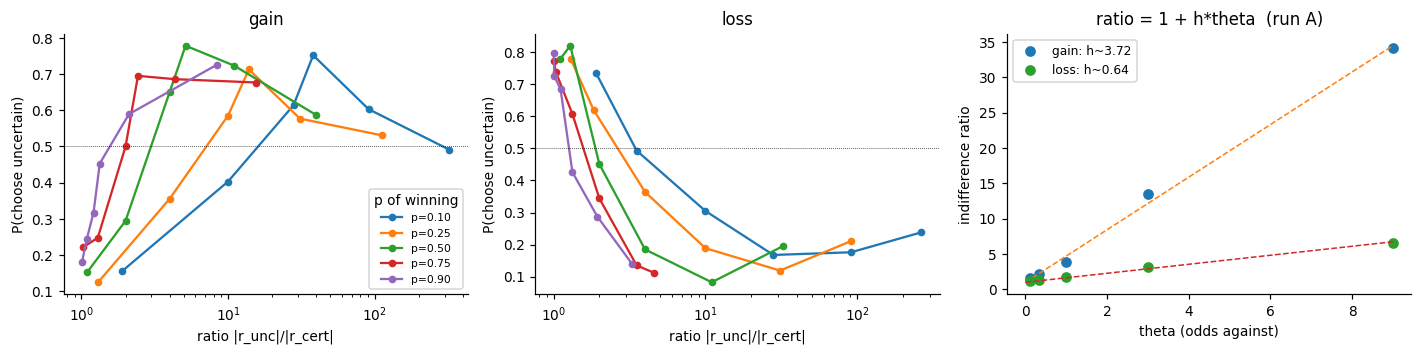

   cond     p  theta  ratio_indiff  slope
0     1  0.10  9.000        34.147  0.598
1     1  0.25  3.000        13.419  0.707
2     1  0.50  1.000         3.830  1.248
3     1  0.75  0.333         2.187  1.750
4     1  0.90  0.111         1.638  2.672
5     2  0.10  9.000         6.612 -0.783
6     2  0.25  3.000         3.205 -1.340
7     2  0.50  1.000         1.767 -2.401
8     2  0.75  0.333         1.348 -3.148
9     2  0.90  0.111         1.227 -4.622

empirical h: {1: 3.719, 2: 0.637}


In [6]:
from scipy.optimize import curve_fit

fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))

# --- Panels 1-2: choice vs. magnitude ratio, by level of p ---
for i, (c, lab) in enumerate([(1, "gain"), (2, "loss")]):
    d = data[data.condition == c]
    for p_val in sorted(d.p.unique()):
        dp = d[d.p == p_val]
        b = pd.qcut(np.log(dp.ratio), 6, duplicates="drop")
        g = dp.groupby(b, observed=True).agg(x=("ratio", "median"), y=("y", "mean"))
        ax[i].plot(g.x, g.y, "o-", ms=4, label=f"p={p_val:.2f}")
    ax[i].set_xscale("log")
    ax[i].axhline(.5, color="k", lw=.5, ls=":")
    ax[i].set(xlabel="ratio |r_unc|/|r_cert|", ylabel="P(choose uncertain)", title=lab)
ax[0].legend(fontsize=7, title="p of winning")

# --- Panel 3: model-free empirical h ---
# At indifference V_unc = V_cert  ->  ratio = 1 + h*theta  (line with slope h)
# Run A only. The rearrangement ratio = 1 + h*theta assumes the smaller option is
# undiscounted (theta_cert == 0). That holds in run A and not in run B, where the
# smaller option is itself probabilistic, so pooling the runs here would bias h.
runA = data[data.run == "A"]
rows = []
for c in [1, 2]:
    sign = 1 if c == 1 else -1          # losses: negative logistic slope
    for p_val in sorted(runA.p.unique()):
        d = runA[(runA.condition == c) & (runA.p == p_val)]
        if d.y.std() == 0:
            continue
        try:
            a, b_ = curve_fit(lambda x, a, b: 1/(1+np.exp(-(a+b*x))),
                              np.log(d.ratio.values), d.y.values,
                              p0=[0, sign], maxfev=20000)[0]
            if np.sign(b_) == sign and abs(b_) > 1e-3:
                rows.append(dict(cond=c, p=p_val, theta=(1-p_val)/p_val,
                                  ratio_indiff=np.exp(-a/b_), slope=b_))
        except Exception:
            pass
IND = pd.DataFrame(rows)

H_EMP = {}
for c, lab in [(1, "gain"), (2, "loss")]:
    d = IND[IND.cond == c]
    if len(d) < 2:
        print(f"WARNING: only {len(d)} indifference points for {lab}")
        continue
    h = float(np.sum(d.theta * (d.ratio_indiff - 1)) / np.sum(d.theta**2))
    H_EMP[c] = h
    ax[2].plot(d.theta, d.ratio_indiff, "o", label=f"{lab}: h~{h:.2f}")
    tt = np.linspace(0, d.theta.max(), 50)
    ax[2].plot(tt, 1 + h*tt, "--", lw=1)
ax[2].set(xlabel="theta (odds against)", ylabel="indifference ratio",
          title="ratio = 1 + h*theta  (run A)")
ax[2].legend(fontsize=8)

plt.tight_layout(); savefig_show("fig1_data")
print(IND.round(3))
print("\nempirical h:", {k: round(v, 3) for k, v in H_EMP.items()})


In [7]:
# ---------- Preprocessing summary (for the methods section) ----------
summary = {
    "participants":           data.participant_id.nunique(),
    "raw_trials":              len(df),
    "final_trials":            len(data),
    "excl_no_response":        int((~df.choice.isin([1, 2])).sum()),
    "excl_fast_rt":            len(df) - int((~df.choice.isin([1, 2])).sum()) - len(data),
    "h_emp_gain":              round(H_EMP.get(1, np.nan), 3),
    "h_emp_loss":              round(H_EMP.get(2, np.nan), 3),
    "flagged_fast_rt":         int(QC.fast.sum()),
    "flagged_extreme_choice":  int(QC.extreme.sum()),
}
print(pd.Series(summary))

print("\ntrials per participant x run x condition cell:")
print(data.groupby(["run", "condition"]).size().unstack())

# ---------- descriptives per condition (for the methods section) ----------
desc = data.groupby("condition").agg(
    trials=("y", "size"), p_uncertain=("y", "mean"),
    rt_median=("rt", "median"), rt_q25=("rt", lambda x: x.quantile(.25)),
    rt_q75=("rt", lambda x: x.quantile(.75)))
desc.index = ["reward", "loss"]
print("\nper condition:")
print(desc.round(3))
print(f"\nbetween-participant SD of P(uncertain): "
      f"{data.groupby(['participant_id','condition']).y.mean().groupby('condition').std().round(3).to_dict()}")
print(f"participant median RT ranges from {data.groupby('participant_id').rt.median().min():.2f}s "
      f"to {data.groupby('participant_id').rt.median().max():.2f}s")
print(f"RT skew: {data.rt.skew():.2f} raw, {np.log(data.rt).skew():.2f} on the log scale "
      f"-- the log transform is what makes a symmetric noise model appropriate")


participants                 49.000
raw_trials                19600.000
final_trials              19427.000
excl_no_response             68.000
excl_fast_rt                105.000
h_emp_gain                    3.719
h_emp_loss                    0.637
flagged_fast_rt               4.000
flagged_extreme_choice        0.000
dtype: float64

trials per participant x run x condition cell:
condition   1.0   2.0
run                  
A          4877  4850
B          4851  4849

per condition:
        trials  p_uncertain  rt_median  rt_q25  rt_q75
reward    9728        0.464      1.811   1.288   2.597
loss      9699        0.432      2.088   1.423   3.028

between-participant SD of P(uncertain): {1.0: 0.144, 2.0: 0.097}
participant median RT ranges from 0.40s to 3.50s
RT skew: 1.55 raw, -0.51 on the log scale -- the log transform is what makes a symmetric noise model appropriate


### 1.4 Are run A and run B comparable?

**The two runs are not the same task.** `p_cert` is `NaN` for every run A trial and present
(0.3-0.7) for every run B trial, in all 49 participants. The runs therefore differ
*structurally*, not only in difficulty:

|  | run A | run B |
|---|---|---|
| smaller option | certain, $\theta_{cert}=0$ | probabilistic, $p_{cert}\in[0.3,0.7]$ |
| larger option | probabilistic, $p\in[0.1,0.9]$ | probabilistic, $p\in[0.1,0.9]$ |
| structure | sure vs. risky | risky vs. risky |

The column names stay `r_cert` / `r_unc` in run B for consistency with run A even though
neither option is certain there; what is genuinely consistent across the runs is *magnitude*,
so run B is small-vs-large with both options risky. Section 2 therefore discounts **both**
options with the same equation, which reduces to $V_{cert}=r_{cert}$ exactly when
$\theta_{cert}=0$; treating the smaller option as certain would misvalue every run B trial.

Where this bites is stated at each step: Section 5 is generalisation of a construct across two
decision contexts rather than test-retest in the strict sense, and Section 6 is extrapolation
to an unseen decision structure rather than held-out prediction of the same task.

The cell below quantifies the remaining, non-structural differences (design coverage and
behaviour).


In [8]:
# ---------- Run A vs run B: are the two sessions comparable? ----------
# Reliability and out-of-sample prediction both treat run B as a rerun of run A.
# It is not exactly one, and the differences shape how the later results read.
print("=== structure ===")
for r in ("A", "B"):
    g = data[data.run == r]
    print(f"run {r}: p_cert present on {g.p_cert.notna().mean():.0%} of trials, "
          f"values {sorted(g.p_cert.dropna().unique())}, "
          f"theta_cert in [{g.theta_cert.min():.2f}, {g.theta_cert.max():.2f}]")
print("participants with all-NaN p_cert in run A:",
      int(data[data.run == "A"].groupby("participant_id").p_cert.apply(lambda s: s.isna().all()).sum()),
      "| with fully-present p_cert in run B:",
      int(data[data.run == "B"].groupby("participant_id").p_cert.apply(lambda s: s.notna().all()).sum()),
      f"| out of {data.participant_id.nunique()}")

rows = []
for pid, g in data.groupby("participant_id"):
    a, b = g[g.run == "A"], g[g.run == "B"]
    lo, hi = np.log(a.ratio).min(), np.log(a.ratio).max()
    rows.append(dict(pid=pid, p_unc_A=a.y.mean(), p_unc_B=b.y.mean(),
                     rt_A=a.rt.median(), rt_B=b.rt.median(),
                     lr_A=np.log(a.ratio).mean(), lr_B=np.log(b.ratio).mean(),
                     outside=((np.log(b.ratio) > hi) | (np.log(b.ratio) < lo)).mean()))
AB = pd.DataFrame(rows).set_index("pid")

print("=== design ===")
print(f"mean log magnitude ratio:  A={AB.lr_A.mean():.2f}   B={AB.lr_B.mean():.2f}")
print(f"run B trials outside the participant's own run A ratio range: "
      f"mean {AB.outside.mean():.1%}, median {AB.outside.median():.1%}, max {AB.outside.max():.1%}")

print("\n=== behaviour ===")
print(f"P(uncertain):  A={AB.p_unc_A.mean():.3f}  B={AB.p_unc_B.mean():.3f}  "
      f"p={wilcoxon(AB.p_unc_A, AB.p_unc_B)[1]:.2g}")
print(f"median RT:     A={AB.rt_A.median():.2f}s  B={AB.rt_B.median():.2f}s  "
      f"faster in B for {(AB.rt_B < AB.rt_A).sum()}/{len(AB)}  "
      f"p={wilcoxon(AB.rt_A, AB.rt_B)[1]:.1g}")

# Does the choice shift survive conditioning on the offer actually presented?
mt = data.copy()
mt["rb"] = pd.qcut(np.log(mt.ratio), 8, duplicates="drop")
cell = (mt.groupby(["participant_id", "run", "condition", "p", "rb"], observed=True)
          .y.mean().reset_index()
          .pivot_table(index=["participant_id", "condition", "p", "rb"],
                       columns="run", values="y", observed=True).dropna())
print(f"\ndesign-matched (participant x condition x p x ratio octile, {len(cell)} cells): "
      f"A={cell.A.mean():.3f}  B={cell.B.mean():.3f}  "
      f"shift={(cell.B - cell.A).mean():+.3f}  p={wilcoxon(cell.A, cell.B)[1]:.2g}")

print("\nRun B is therefore neither a replication of the run A design nor a fresh draw from")
print("the same behaviour: the smaller option is itself risky, the offers move to larger")
print("ratios, responses speed up markedly, and a small shift towards the uncertain option")
print("survives conditioning on the offer.")
print("Section 3 fixes tau and a from run A, so the speed-up is absorbed nowhere: it is the")
print("main reason the out-of-sample RT likelihood sits well below the in-sample one.")


=== structure ===
run A: p_cert present on 0% of trials, values [], theta_cert in [0.00, 0.00]
run B: p_cert present on 100% of trials, values [np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7)], theta_cert in [0.43, 2.33]
participants with all-NaN p_cert in run A: 49 | with fully-present p_cert in run B: 49 | out of 49
=== design ===
mean log magnitude ratio:  A=1.32   B=1.73
run B trials outside the participant's own run A ratio range: mean 23.0%, median 17.0%, max 74.5%

=== behaviour ===
P(uncertain):  A=0.394  B=0.503  p=0.00096
median RT:     A=2.19s  B=1.77s  faster in B for 45/49  p=2e-12



design-matched (participant x condition x p x ratio octile, 1440 cells): A=0.431  B=0.469  shift=+0.038  p=0.0015

Run B is therefore neither a replication of the run A design nor a fresh draw from
the same behaviour: the smaller option is itself risky, the offers move to larger
ratios, responses speed up markedly, and a small shift towards the uncertain option
survives conditioning on the offer.
Section 3 fixes tau and a from run A, so the speed-up is absorbed nowhere: it is the
main reason the out-of-sample RT likelihood sits well below the in-sample one.


## 2. Valuation model & choice rule

**Valuation model — Rachlin hyperboloid-in-odds probability discounting** (Rachlin,
Raineri & Cross, 1991). **Both** options are discounted by the odds against their own
outcome, $\theta_i = (1-p_i)/p_i$:
$$V_i(h) = \frac{r_i}{1 + h\,\theta_i}, \qquad h \ge 0$$

In run A the smaller option is delivered with certainty, so $\theta_{cert}=0$ and the
equation reduces exactly to $V_{cert}=r_{cert}$. In run B the smaller option is itself
probabilistic ($p_{cert}\in[0.3,0.7]$, i.e. $\theta_{cert}\in[0.43,2.33]$) and is
discounted like any other. One equation covers both runs; hard-coding $V_{cert}=r_{cert}$
would overstate the smaller option's value by a factor $1+h\theta_{cert}$ on every run B
trial, which at the fitted rates is between $1.3\times$ and $8.6\times$.

The hyperbolic form is supported by our own data, not assumed: at indifference the equation rearranges to $r_{unc}/r_{cert} = 1 + h\theta$, so indifference ratios should be **linear in θ**. The non-parametric estimates in Section 1, computed on run A only, fall close to that line (h ≈ 3.72 gains, h ≈ 0.64 losses) and serve as a validation target for the fitted parameters.

- Two rates per participant: (h_gain, h_loss). The design is fully crossed (100 trials per
condition per run), and the two model-free rates differ by nearly an order of magnitude, so a
single rate would fit neither domain.
- Sign handling: Loss magnitudes are stored as negative (verified with the data). No sign correction is applied, the same equation then produces both risk attitudes: for gains V_unc shrinks toward 0 and so is *worse* than the sure gain (risk aversion); for losses it shrinks toward 0 and so is *better* than the sure loss (risk seeking). The reflection effect emerges with no extra parameter.
- Scaling: $\Delta V = (V_{unc} − V_{cert}) / [(|r_{cert}| + |r_{unc}|)/2]$. Purely numerical, magnitudes span five orders of magnitude, so without normalisation no single β could serve both small and large trials. The cost is that absolute magnitude effects cannot be expressed through this predictor.


**Choice rule (logistic on $\Delta V$):**

$$P(\text{uncertain}) = \sigma(\beta\,\Delta V + \beta_0)$$

$\beta$ is choice sensitivity (large $\beta$ = choices follow value deterministically); $\beta_0$ absorbs a value-independent bias. **Consistent with Section 1:** the model-free choice curves there (binned by magnitude ratio, separately by θ) already show the qualitative pattern this valuation model predicts — monotonic in the ratio, with the reward and loss conditions moving in opposite directions around the point of indifference.

**Parameterisation and likelihood**
Four parameters per participant, fitted unconstrained: `log_h_gain`, `log_h_loss`, `log_beta` (log scale keeps rates positive without bounded optimisation and improves conditioning) and `beta0` (unconstrained; bias may point either way).

$$\mathcal{L}_{choice} = \sum_t \big[ y_t \log P_t + (1-y_t)\log(1-P_t) \big]$$

This term is identical in every model, including the choice-only baseline. The RT models add a second term; the baseline omits it. The two likelihoods describe different data and are not directly comparable.

**Limitations**
* One β across conditions, though choices tracked value more sharply for losses.
* Normalising ΔV removes magnitude effects.
* h and β assumed constant within a run (no learning, fatigue, or drift).


**The RT distribution (held fixed): Shifted log-normal**

The brief requires that the noise distribution be identical across all RT models. If it varied, the comparison would partly measure distributional shape rather than isolating the value→RT mapping, which is the object of interest.

$$RT = \tau + \exp(\mu + \sigma\varepsilon), \qquad \varepsilon \sim \mathcal{N}(0,1)$$

**Log-density.** For rt > τ:

$$\log f(rt) = -\log(rt-\tau) - \log\sigma - \tfrac{1}{2}\log 2\pi
- \tfrac{1}{2}\left[\frac{\log(rt-\tau) - \mu}{\sigma}\right]^2$$

### Parameters

| Fitted | Recovered as | Role |
|---|---|---|
| `a`, `b` | — | Define μ; this is the only part that differs across models. |
| `log_sigma` | σ = exp(·) | RT variability on the log scale; must be positive. |
| `tau_raw` | τ = logistic(τ_raw)·0.99·min(RT) | Non-decision time. |


### 2.1 The RT models

All models share the valuation model, the choice rule, and the shifted log-normal above. They
differ only in how ΔV enters the location parameter μ.

### M1 — Linear conflict

$$\mu = a - b\,|\Delta V|$$

**Hypothesis.** Response time is driven by the *distance between the options in value space*.
The further apart they are, the faster the comparison resolves; when ΔV ≈ 0 the comparison
stalls and the response is delayed.

**Motivation.** In an evidence-accumulation (diffusion) process the drift rate is proportional
to the value difference, and mean decision time decreases approximately linearly in drift for
small drift rates. M1 is that first-order approximation.

### M2 — Decision uncertainty

$$\mu = a - b\,\big|2P(\text{uncertain}) - 1\big|$$

**Hypothesis.** What slows responding is not the objective value distance but *subjective
indecision*. The predictor measures how far the choice probability sits from 50/50: it is 0
under complete indecision and 1 under complete certainty.

**How it differs psychologically from M1.** The difference is **saturation**. Under M1,
each additional unit of ΔV always speeds responding by the same amount. Under M2, once the
participant is already nearly certain (P ≈ 0.95), further value advantage buys no additional
speed — the predictor has reached ceiling. M1 says RT tracks value; M2 says RT tracks
confidence.

### M3 — Quadratic conflict

$$\mu = a - b\,(\Delta V)^2$$

**Hypothesis.** Slowing is *concentrated at indifference*. Only near-ties are genuinely costly:
once one option holds any appreciable advantage the deliberation cost falls away quickly, and
further advantage beyond that buys progressively more speed rather than less.

**How it differs psychologically from M1 and M2.** All three are decreasing in |ΔV|, but the
curvature differs, and curvature is the psychological claim. M1 is linear: every unit of value
advantage is worth the same amount of time. M3 is convex in the predictor, so the marginal
speed-up *grows* with |ΔV| — the model asserts that difficulty is a sharply peaked function of
value distance, negligible except in a narrow band around indifference. M2 goes the opposite
way, with the marginal speed-up *shrinking* to zero at high certainty. The three therefore
bracket the plausible shapes: accelerating (M3), constant (M1), and decelerating (M2) returns
to value advantage.


### Summary of the distinction

| | Predictor | What slows the participant | Marginal effect as \|ΔV\| grows |
|---|---|---|---|
| **M1** | \|ΔV\| | Value distance | Constant |
| **M2** | \|2P−1\| | Subjective indecision | Shrinks (saturates) |
| **M3** | ΔV² | Proximity to indifference | Grows (accelerates) |

In [9]:
from scipy.special import expit

# ==================== valuation & choice (FIXED) ====================
CHOICE_PARS = ["log_h_gain", "log_h_loss", "log_beta", "beta0"]

def compute_dv(pars, d):
    """Normalized value difference. Magnitudes are already signed: no sign correction applied.

    Both options are discounted by the odds against their own outcome. In run A
    theta_cert == 0, so V_cert reduces to r_cert and this is identical to the
    sure-vs-risky form; in run B the smaller option is risky and is discounted too."""
    h      = np.where(d.condition.values == 2,
                      np.exp(pars["log_h_loss"]), np.exp(pars["log_h_gain"]))
    V_cert = d.r_cert.values / (1.0 + h * d.theta_cert.values)
    V_unc  = d.r_unc.values  / (1.0 + h * d.theta.values)
    return (V_unc - V_cert) / d.scale.values

def choice_prob(pars, dv):
    z = np.clip(np.exp(pars["log_beta"]) * dv + pars["beta0"], -500, 500)
    return np.clip(expit(z), 1e-12, 1 - 1e-12)

def ll_choice(pars, d, dv=None, pu=None):
    """Choice log-likelihood, per trial (Bernoulli)."""
    dv = compute_dv(pars, d) if dv is None else dv
    pu = choice_prob(pars, dv) if pu is None else pu
    y  = d.y.values
    return y * np.log(pu) + (1 - y) * np.log(1 - pu)

# ==================== RT distribution (FIXED) ====================
RT_PARS  = ["a", "b", "log_sigma", "tau_raw"]
LL_FLOOR = -20.0     # finite floor for rt <= tau

def get_tau(pars, rt_min):
    """0 < tau < min(RT), guaranteed by the sigmoid transform."""
    return expit(pars["tau_raw"]) * 0.99 * rt_min

def ll_rt(pars, model, d, dv, pu, rt_min, return_viol=False):
    """Shifted log-normal, IDENTICAL across all models: only mu changes."""
    tau   = get_tau(pars, rt_min)
    sigma = np.exp(pars["log_sigma"])
    mu    = rt_location(pars, model, dv, pu)
    resid = d.rt.values - tau
    ok    = resid > 1e-6
    rr    = np.where(ok, resid, 1.0)
    z     = (np.log(rr) - mu) / sigma
    ll    = -np.log(rr) - np.log(sigma) - 0.5*np.log(2*np.pi) - 0.5*z**2
    out   = np.where(ok, ll, LL_FLOOR)
    return (out, int((~ok).sum())) if return_viol else out

# ==================== RT models ====================
RT_MODELS = ["M1_abs", "M2_unc", "M3_sq"]

def rt_location(pars, model, dv, pu):
    a, b = pars["a"], pars["b"]
    if model == "M1_abs":
        return a - b * np.abs(dv)              # value distance
    if model == "M2_unc":
        return a - b * np.abs(2 * pu - 1)      # decision uncertainty
    if model == "M3_sq":
        return a - b * dv**2                   # proximity to indifference
    raise ValueError(f"unknown model: {model}")

# ==================== joint likelihood ====================
def log_lik(pars, d, model=None, rt_min=None, use_rt=True):
    """model=None or use_rt=False -> choice-only baseline."""
    dv  = compute_dv(pars, d)
    pu  = choice_prob(pars, dv)
    llc = ll_choice(pars, d, dv, pu)
    if not use_rt or model is None:
        return dict(total=llc.sum(), choice=llc.sum(), rt=np.nan)
    llr = ll_rt(pars, model, d, dv, pu, rt_min)
    return dict(total=llc.sum() + llr.sum(), choice=llc.sum(), rt=llr.sum())

def param_names(model, use_rt=True):
    return CHOICE_PARS + (RT_PARS if (use_rt and model) else [])


## 3. Infer (run A)



### Estimator: per-participant MAP

Parameters are estimated **separately for each participant** by maximum a posteriori,
using run A only. Run B is never touched at this stage.

### Likelihood

For participant *i*, trial *t*, with $y_t = 1$ if the uncertain option was chosen:

$$\mathcal{L}_i = \underbrace{\sum_t \big[y_t\log P_t + (1-y_t)\log(1-P_t)\big]}_{\text{choice}}
\; + \; \underbrace{\sum_t \log f(rt_t \mid \mu_t, \sigma, \tau)}_{\text{RT (omitted in the baseline)}}$$

with $P_t = \sigma(\beta\Delta V_t + \beta_0)$ and $f$ the shifted log-normal density of
Section 2. The **choice-only baseline** uses the identical first term with the second deleted:
it is the same model fitted to one modality, not a different model.

### Priors

Weakly informative Gaussian priors on the transformed (fitted) scale:

| Parameter | Prior | Rationale |
|---|---|---|
| `log_h_gain`, `log_h_loss` | N(0, 2²) | Centred at h = 1 (no strong stance), 95% mass over h ∈ [0.02, 55] — far wider than the model-free estimates of 3.72 and 0.64, so the data dominate. |
| `log_beta` | N(1, 1.5²) | Covers β ∈ [0.14, 52]. Rules out only numerically degenerate values. |
| `beta0` | N(0, 2²) | No stance on the direction of bias. |
| `a` | N(0.5, 1²) | Centred near log(median RT − τ) ≈ 0.6. |
| `b` | N(0, 1²) | **Centred at zero and symmetric**: the prior takes no position on whether difficulty slows or speeds responding, so a positive b is not assumed. |
| `log_sigma` | N(−0.5, 0.5²) | Matches the observed spread of log RT. |
| `tau_raw` | N(0, 1.5²) | Nearly flat over the admissible interval (0, min RT). |



In [10]:
from scipy.optimize import minimize
import hashlib, time

# Gaussian priors on the fitted scale: name -> (mean, sd)
PRIORS = {
    "log_h_gain": (0.0,  2.0),  "log_h_loss": (0.0,  2.0),
    "log_beta":   (1.0,  1.5),  "beta0":      (0.0,  2.0),
    "a":          (0.5,  1.0),  "b":          (0.0,  1.0),
    "log_sigma":  (-0.5, 0.5),  "tau_raw":    (0.0,  1.5),
}
# M3's predictor (ΔV²) lives on a smaller scale (median 0.08 vs 0.28 for |ΔV|), so an
# equivalent effect on mu needs a larger b. Widening its prior keeps the regularisation
# comparable in terms of the *effect*, not the raw coefficient — otherwise M3 would be
# penalised more heavily than M1/M2 and the model comparison would be unfair.
PRIOR_B = {"M1_abs": (0.0, 1.0), "M2_unc": (0.0, 1.0), "M3_sq": (0.0, 3.0)}

BOUNDS = {
    "log_h_gain": (-8, 6),  "log_h_loss": (-8, 6),
    "log_beta":   (-4, 6),  "beta0":      (-8, 8),
    "a":          (-4, 4),  "b":          (-6, 6),
    "log_sigma":  (-3, 2),  "tau_raw":    (-6, 6),
}

def _prior_of(name, model):
    return PRIOR_B[model] if (name == "b" and model in PRIOR_B) else PRIORS[name]

def log_prior(pars, names, model=None):
    tot = 0.0
    for n in names:
        m_, s_ = _prior_of(n, model)
        tot += -0.5 * ((pars[n] - m_) / s_) ** 2
    return tot

def neg_log_post(x, d, names, model, rt_min, use_rt, use_prior=True):
    pars = dict(zip(names, x))
    val = log_lik(pars, d, model, rt_min, use_rt)["total"]
    if use_prior:
        val += log_prior(pars, names, model)
    return 1e10 if not np.isfinite(val) else -val

def _inits(names, rng, k, model=None):
    """k=0: start informed by Step 1. k>0: samples from the prior."""
    if k == 0:
        seed = dict(log_h_gain=np.log(H_EMP[1]), log_h_loss=np.log(H_EMP[2]),
                    log_beta=1.0, beta0=0.0, a=0.5,
                    b=0.6 if model == "M3_sq" else 0.2,
                    log_sigma=-0.5, tau_raw=0.0)
        x = [seed[n] for n in names]
    else:
        x = [(lambda m_, s_: m_ + 0.8 * s_ * rng.standard_normal())(*_prior_of(n, model))
             for n in names]
    return np.array([np.clip(v, BOUNDS[n][0] + 1e-3, BOUNDS[n][1] - 1e-3)
                     for v, n in zip(x, names)])

def fit_one(d, model, use_rt=True, n_restart=10, seed=0, use_prior=True):
    """MAP fit (or MLE if use_prior=False) for one participant-run."""
    names  = param_names(model, use_rt)
    rt_min = float(d.rt.min())
    rng    = np.random.default_rng(seed)
    best   = None
    for k in range(n_restart):
        try:
            res = minimize(neg_log_post, _inits(names, rng, k, model),
                           args=(d, names, model, rt_min, use_rt, use_prior),
                           method="L-BFGS-B", bounds=[BOUNDS[n] for n in names],
                           options=dict(maxiter=3000, ftol=1e-11))
        except Exception:
            continue
        if np.isfinite(res.fun) and (best is None or res.fun < best.fun):
            best = res
    if best is None:
        return None
    pars = dict(zip(names, best.x))
    lls  = log_lik(pars, d, model, rt_min, use_rt)
    return dict(pars=pars, rt_min=rt_min,
                ll_total=lls["total"], ll_choice=lls["choice"], ll_rt=lls["rt"],
                n_par=len(names), n_trial=len(d), converged=bool(best.success))

In [11]:
ALL_MODELS = ["baseline"] + RT_MODELS          # baseline, M1_abs, M2_unc, M3_sq
SUBJ = sorted(data.participant_id.unique())

def stable_seed(*parts):
    """Deterministic seed: Python's hash() is randomised per process for strings."""
    return int(hashlib.md5("|".join(map(str, parts)).encode()).hexdigest(), 16) % (2**31)

def fit_all(models=ALL_MODELS, runs=("A",), n_restart=10, use_prior=True):
    out = {m: {r: {} for r in runs} for m in models}
    for m in models:
        t0, mdl = time.time(), (None if m == "baseline" else m)
        for r in runs:
            for s in SUBJ:
                d = data[(data.participant_id == s) & (data.run == r)]
                out[m][r][s] = fit_one(d, mdl, use_rt=(mdl is not None),
                                       n_restart=n_restart, seed=stable_seed(m, r, s),
                                       use_prior=use_prior)
        print(f"{m:10s} done in {time.time()-t0:5.1f}s")
    return out

def par_table(fits, model, run="A"):
    rows = []
    for s, f in fits[model][run].items():
        if f is None:
            continue
        row = dict(f["pars"]); row["sid"] = s
        if "tau_raw" in row:
            row["tau"] = get_tau(f["pars"], f["rt_min"])
        row.update(ll_choice=f["ll_choice"], ll_rt=f["ll_rt"], conv=f["converged"])
        rows.append(row)
    t = pd.DataFrame(rows).set_index("sid")
    t["h_gain"], t["h_loss"] = np.exp(t.log_h_gain), np.exp(t.log_h_loss)
    t["beta"] = np.exp(t.log_beta)
    if "log_sigma" in t:
        t["sigma"] = np.exp(t.log_sigma)
    return t

FITS   = fit_all()
PARS_A = {m: par_table(FITS, m, "A") for m in ALL_MODELS}

print("\nconvergence:", {m: f"{PARS_A[m].conv.mean():.0%}" for m in ALL_MODELS})
print("\n--- run A estimates (median across participants) ---")
print(pd.DataFrame({m: PARS_A[m][["h_gain","h_loss","beta","beta0"]].median()
                    for m in ALL_MODELS}).round(3))
print("empirical h (Step 1):", {k: round(v,3) for k,v in H_EMP.items()})

print("\n--- difficulty effect ---")
print("NOTE: b is not comparable across models (predictors are on different scales)")
for m in RT_MODELS:
    b = PARS_A[m].b
    print(f"{m:8s}: median b={b.median():+.3f}, b>0 in {(b>0).sum()}/{len(b)}, "
          f"mean ll_rt={PARS_A[m].ll_rt.mean():.1f}")

# in-sample paired comparison (indicative only; the valid test is out-of-sample, Step 6)
L = pd.DataFrame({m: PARS_A[m].ll_rt for m in RT_MODELS})
print("\nin-sample paired comparisons (run A):")
for m1, m2 in [("M1_abs","M2_unc"), ("M1_abs","M3_sq"), ("M2_unc","M3_sq")]:
    d_ = L[m2] - L[m1]
    print(f"  {m2} − {m1}: mean={d_.mean():+6.2f}, {m2} wins {(d_>0).sum()}/{len(d_)}, "
          f"p={wilcoxon(d_)[1]:.3f}")
print("best model per participant:", L.idxmax(axis=1).value_counts().to_dict())

baseline   done in  11.9s


M1_abs     done in  58.6s


M2_unc     done in  70.5s


M3_sq      done in  53.6s

convergence: {'baseline': '100%', 'M1_abs': '100%', 'M2_unc': '100%', 'M3_sq': '100%'}

--- run A estimates (median across participants) ---
        baseline  M1_abs  M2_unc  M3_sq
h_gain     2.652   2.639   1.876  3.163
h_loss     0.817   0.979   1.082  0.841
beta       4.527   4.537   4.131  4.467
beta0     -0.242  -0.504  -0.459 -0.236
empirical h (Step 1): {1: 3.719, 2: 0.637}

--- difficulty effect ---
NOTE: b is not comparable across models (predictors are on different scales)
M1_abs  : median b=+0.106, b>0 in 29/49, mean ll_rt=-258.6
M2_unc  : median b=+0.295, b>0 in 38/49, mean ll_rt=-256.0
M3_sq   : median b=+0.149, b>0 in 33/49, mean ll_rt=-258.2

in-sample paired comparisons (run A):
  M2_unc − M1_abs: mean= +2.57, M2_unc wins 32/49, p=0.005
  M3_sq − M1_abs: mean= +0.37, M3_sq wins 26/49, p=0.723
  M3_sq − M2_unc: mean= -2.20, M3_sq wins 17/49, p=0.015
best model per participant: {'M2_unc': 29, 'M3_sq': 11, 'M1_abs': 9}


In [12]:
# ---- MLE (same restarts as the MAP fit) ----
mle = {}
for s in SUBJ:
    d = data[(data.participant_id == s) & (data.run == "A")]
    f = fit_one(d, None, use_rt=False, n_restart=10, seed=1, use_prior=False)
    if f: mle[s] = f["pars"]
MLE = pd.DataFrame(mle).T
cmp = PARS_A["baseline"][CHOICE_PARS].join(MLE, rsuffix="_mle").dropna()

# ---- curvature diagnostic: how much likelihood is lost moving each parameter? ----
def curvature(sid, p_name, delta=0.5):
    d = data[(data.participant_id == sid) & (data.run == "A")]
    pars = dict(MLE.loc[sid])
    ll0 = log_lik(pars, d, None, use_rt=False)["total"]
    return min(ll0 - log_lik({**pars, p_name: pars[p_name] + s}, d,
                             None, use_rt=False)["total"] for s in (-delta, +delta))

DIAG = pd.DataFrame({p: [curvature(s, p) for s in cmp.index] for p in CHOICE_PARS},
                    index=cmp.index)
POORLY_ID = (DIAG < 0.5).any(axis=1)

print(f"poorly identified: {POORLY_ID.sum()} of {len(DIAG)}")
print("flat in each parameter:", (DIAG < 0.5).sum().to_dict())

print("\n=== MAP vs MLE ===")
sub = cmp[~POORLY_ID.values]
for p in CHOICE_PARS:
    print(f"{p:12s} r(all)={np.corrcoef(cmp[p], cmp[p+'_mle'])[0,1]:.3f}  "
          f"r(identified, n={len(sub)})={np.corrcoef(sub[p], sub[p+'_mle'])[0,1]:.4f}  "
          f"median dev={abs(sub[p]-sub[p+'_mle']).median():.4f}")

print("\noverlap with fast-RT flagged participants:",
      sorted(set(QC.index[QC.fast]) & set(DIAG.index[POORLY_ID])))

poorly identified: 19 of 49
flat in each parameter: {'log_h_gain': 14, 'log_h_loss': 14, 'log_beta': 3, 'beta0': 1}

=== MAP vs MLE ===
log_h_gain   r(all)=0.743  r(identified, n=30)=0.9987  median dev=0.0872
log_h_loss   r(all)=0.754  r(identified, n=30)=0.9972  median dev=0.0914
log_beta     r(all)=0.742  r(identified, n=30)=0.9994  median dev=0.0080
beta0        r(all)=0.711  r(identified, n=30)=0.9952  median dev=0.1250

overlap with fast-RT flagged participants: ['bh348lli7', 'orxx7nl6z', 's4xqtibhr']


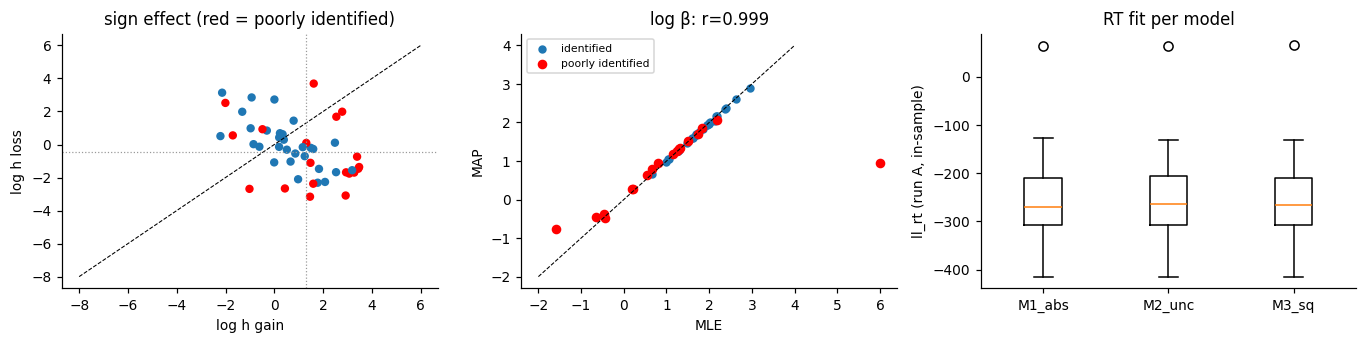

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))

# (a) sign effect, poorly identified in red
t = PARS_A["baseline"]
ax[0].scatter(t.log_h_gain, t.log_h_loss, s=20,
              c=np.where(POORLY_ID.reindex(t.index, fill_value=False), "r", "C0"))
ax[0].plot([-8, 6], [-8, 6], "k--", lw=.7)
ax[0].axvline(np.log(H_EMP[1]), color="0.6", lw=.8, ls=":")
ax[0].axhline(np.log(H_EMP[2]), color="0.6", lw=.8, ls=":")
ax[0].set(xlabel="log h gain", ylabel="log h loss",
          title="sign effect (red = poorly identified)")

# (b) priors do not move the well-identified estimates
ax[1].scatter(sub.log_beta_mle, sub.log_beta, s=20, label="identified")
ax[1].scatter(cmp.loc[POORLY_ID.values, "log_beta_mle"],
              cmp.loc[POORLY_ID.values, "log_beta"], s=28, c="r", label="poorly identified")
ax[1].plot([-2, 4], [-2, 4], "k--", lw=.7)
ax[1].set(xlabel="MLE", ylabel="MAP",
          title=f"log β: r={np.corrcoef(sub.log_beta, sub.log_beta_mle)[0,1]:.3f}")
ax[1].legend(fontsize=7)

# (c) in-sample RT fit (b itself is not comparable across models)
ax[2].boxplot([L[c] for c in L.columns])
ax[2].set_xticks(range(1, len(L.columns)+1)); ax[2].set_xticklabels(L.columns)
ax[2].set(ylabel="ll_rt (run A, in-sample)", title="RT fit per model")

plt.tight_layout(); savefig_show("fig2_insample")

## 4. Parameter recovery

### 4.1 Simulator

In [14]:
def simulate(pars, design, model, rng, tau_sec):
    """Generates choices and RTs from known parameters, over a real trial design."""
    d = design.copy().reset_index(drop=True)
    dv = compute_dv(pars, d)
    pu = choice_prob(pars, dv)
    d["y"] = (rng.random(len(d)) < pu).astype(float)
    d["choice"] = d.y + 1
    mu = rt_location(pars, model, dv, pu)
    d["rt"] = tau_sec + np.exp(mu + np.exp(pars["log_sigma"]) * rng.standard_normal(len(d)))
    return d[d.rt >= RT_LO].reset_index(drop=True)     # same cleaning as the real data

# generating ranges, informed by Step 3's estimates
GEN = dict(log_h_gain=(-2.0, 3.5), log_h_loss=(-3.0, 2.5),
           log_beta=(0.0, 2.9), beta0=(-2.0, 2.0),
           a=(0.2, 0.9), log_sigma=(-1.0, -0.2))       # 'b' is model-dependent
# M3's predictor (ΔV²) is ~3.5x smaller in scale than |ΔV|, so an equivalent effect on mu
# requires a proportionally larger b. Using one range for all models would simulate a
# near-null effect under M3 and make its recovery look artificially poor.
GEN_B = {"M1_abs": (-0.2, 1.0), "M2_unc": (-0.2, 1.0), "M3_sq": (-0.5, 3.0)}
TAU_RANGE = (0.10, 0.24)     # below the observed minimum RT (0.25 s)

def draw_true(rng, model):
    p = {k: rng.uniform(*v) for k, v in GEN.items()}
    p["b"] = rng.uniform(*GEN_B[model])
    return p, rng.uniform(*TAU_RANGE)

### 4.2 Recovery 

In [15]:
N_REC, N_RESTART_REC = 200, 5
DESIGN_COLS = ["r_cert", "r_unc", "theta", "theta_cert", "condition", "scale"]

def recovery(model, run="A", n_rep=N_REC, seed=7):
    rng, rows, skipped = np.random.default_rng(seed), [], 0
    for i in range(n_rep):
        p_true, tau = draw_true(rng, model)
        sid = SUBJ[rng.integers(len(SUBJ))]
        design = data[(data.participant_id == sid) & (data.run == run)][DESIGN_COLS]
        sim = simulate(p_true, design, model, rng, tau)
        # a replicate with almost no choice variance carries no information about h or beta
        if len(sim) < 100 or not (0.02 < sim.y.mean() < 0.98):
            skipped += 1
            continue
        f_full = fit_one(sim, model, use_rt=True,  n_restart=N_RESTART_REC,
                         seed=stable_seed("rec", model, i, "full"))
        f_cho  = fit_one(sim, None,  use_rt=False, n_restart=N_RESTART_REC,
                         seed=stable_seed("rec", model, i, "cho"))
        if f_full is None or f_cho is None:
            skipped += 1
            continue
        est_f = dict(f_full["pars"]); est_f["tau"] = get_tau(f_full["pars"], f_full["rt_min"])
        truth = dict(p_true); truth["tau"] = tau
        for n, v in truth.items():
            rows.append(dict(model=model, rep=i, param=n, true=v,
                             est_full=est_f.get(n, np.nan),
                             est_choice=f_cho["pars"].get(n, np.nan)))
    if skipped:
        print(f"  {model}: {skipped} replicates skipped")
    return pd.DataFrame(rows)

t0 = time.time()
REC = pd.concat([recovery(m) for m in RT_MODELS], ignore_index=True)
print(f"recovery completed in {time.time()-t0:.0f}s "
      f"({REC.groupby('model').rep.nunique().to_dict()} replicates)")

def stats(g, col):
    g = g.dropna(subset=["true", col])
    if len(g) < 5:
        return pd.Series(dict(r=np.nan, rmse=np.nan, bias=np.nan, n=len(g)))
    return pd.Series(dict(r=pearsonr(g["true"], g[col])[0],
                          rmse=np.sqrt(np.mean((g["true"] - g[col])**2)),
                          bias=np.mean(g[col] - g["true"]), n=len(g)))

REC_FULL = REC.groupby(["model","param"])[["true","est_full"]].apply(stats, col="est_full").round(3)
print("\n=== recovery with RT (choice + RT) ===")
print(REC_FULL)
print("\nNOTE: b was generated on a model-specific range, so its RMSE is not comparable "
      "across models; the correlation r is.")

recovery completed in 416s ({'M1_abs': 200, 'M2_unc': 200, 'M3_sq': 200} replicates)

=== recovery with RT (choice + RT) ===
                       r   rmse   bias      n
model  param                                 
M1_abs a           0.884  0.107 -0.036  200.0
       b           0.897  0.184  0.028  200.0
       beta0       0.954  0.371 -0.036  200.0
       log_beta    0.955  0.266  0.041  200.0
       log_h_gain  0.925  0.569 -0.063  200.0
       log_h_loss  0.958  0.486  0.082  200.0
       log_sigma   0.917  0.097  0.032  200.0
       tau         0.187  0.110  0.055  200.0
M2_unc a           0.825  0.145 -0.018  200.0
       b           0.860  0.210  0.034  200.0
       beta0       0.952  0.382 -0.040  200.0
       log_beta    0.958  0.253  0.062  200.0
       log_h_gain  0.900  0.649 -0.074  200.0
       log_h_loss  0.936  0.598  0.118  200.0
       log_sigma   0.914  0.098  0.028  200.0
       tau         0.207  0.103  0.049  200.0
M3_sq  a           0.928  0.086 -0.035  200.0
 

### 4.3 Analysis


In [16]:
REC_CHO = (REC[REC.param.isin(CHOICE_PARS)]
           .groupby(["model","param"])[["true","est_choice"]]
           .apply(stats, col="est_choice").round(3))

CMP = (REC_FULL.loc[:, ["r","rmse"]]
       .join(REC_CHO.loc[:, ["r","rmse"]], lsuffix="_rt", rsuffix="_choice", how="inner"))
CMP["Δr"] = (CMP.r_rt - CMP.r_choice).round(3)
CMP["rmse_ratio"] = (CMP.rmse_rt / CMP.rmse_choice).round(3)   # <1 = RT helps
print("=== with RT vs. choice-only (rmse_ratio < 1 = RT improves recovery) ===")
print(CMP)

print("\n=== paired test (Wilcoxon on |error|) ===")
rows = []
for m in RT_MODELS:
    for p in CHOICE_PARS:
        g = REC[(REC.model == m) & (REC.param == p)].dropna()
        e_rt, e_so = (g.est_full - g["true"]).abs(), (g.est_choice - g["true"]).abs()
        pv = wilcoxon(e_rt, e_so)[1]
        rows.append(dict(model=m, param=p, err_rt=e_rt.median(),
                         err_choice=e_so.median(), better=int((e_rt < e_so).sum()),
                         n=len(g), p=pv))
        print(f"{m:8s} {p:12s}: |err| RT={e_rt.median():.3f} "
              f"choice-only={e_so.median():.3f}  p={pv:.4f}")
RT_HELPS_REC = pd.DataFrame(rows).round(4)

=== with RT vs. choice-only (rmse_ratio < 1 = RT improves recovery) ===
                    r_rt  rmse_rt  r_choice  rmse_choice     Δr  rmse_ratio
model  param                                                               
M1_abs beta0       0.954    0.371     0.940        0.427  0.014       0.869
       log_beta    0.955    0.266     0.951        0.276  0.004       0.964
       log_h_gain  0.925    0.569     0.899        0.660  0.026       0.862
       log_h_loss  0.958    0.486     0.917        0.676  0.041       0.719
M2_unc beta0       0.952    0.382     0.940        0.427  0.012       0.895
       log_beta    0.958    0.253     0.951        0.276  0.007       0.917
       log_h_gain  0.900    0.649     0.899        0.660  0.001       0.983
       log_h_loss  0.936    0.598     0.917        0.677  0.019       0.883
M3_sq  beta0       0.963    0.326     0.940        0.429  0.023       0.760
       log_beta    0.956    0.263     0.948        0.285  0.008       0.923
       log_h_gai

In [17]:
print("=== tau/a trade-off (why tau is not identifiable) ===")
for m in RT_MODELS:
    sub = REC[REC.model == m]
    T = sub.pivot(index="rep", columns="param", values="true")
    E = sub.pivot(index="rep", columns="param", values="est_full")
    err = pd.DataFrame({"tau": E.tau - T.tau, "a": E.a - T.a}).dropna()
    print(f"{m:8s}: r(tau)={pearsonr(T.tau.dropna(), E.tau.dropna())[0]:+.3f}  "
          f"corr(err_tau, err_a)={err.tau.corr(err.a):+.3f}  "
          f"bias_tau={err.tau.mean():+.4f}s")

=== tau/a trade-off (why tau is not identifiable) ===
M1_abs  : r(tau)=+0.187  corr(err_tau, err_a)=-0.638  bias_tau=+0.0549s
M2_unc  : r(tau)=+0.207  corr(err_tau, err_a)=-0.382  bias_tau=+0.0485s
M3_sq   : r(tau)=+0.287  corr(err_tau, err_a)=-0.635  bias_tau=+0.0477s


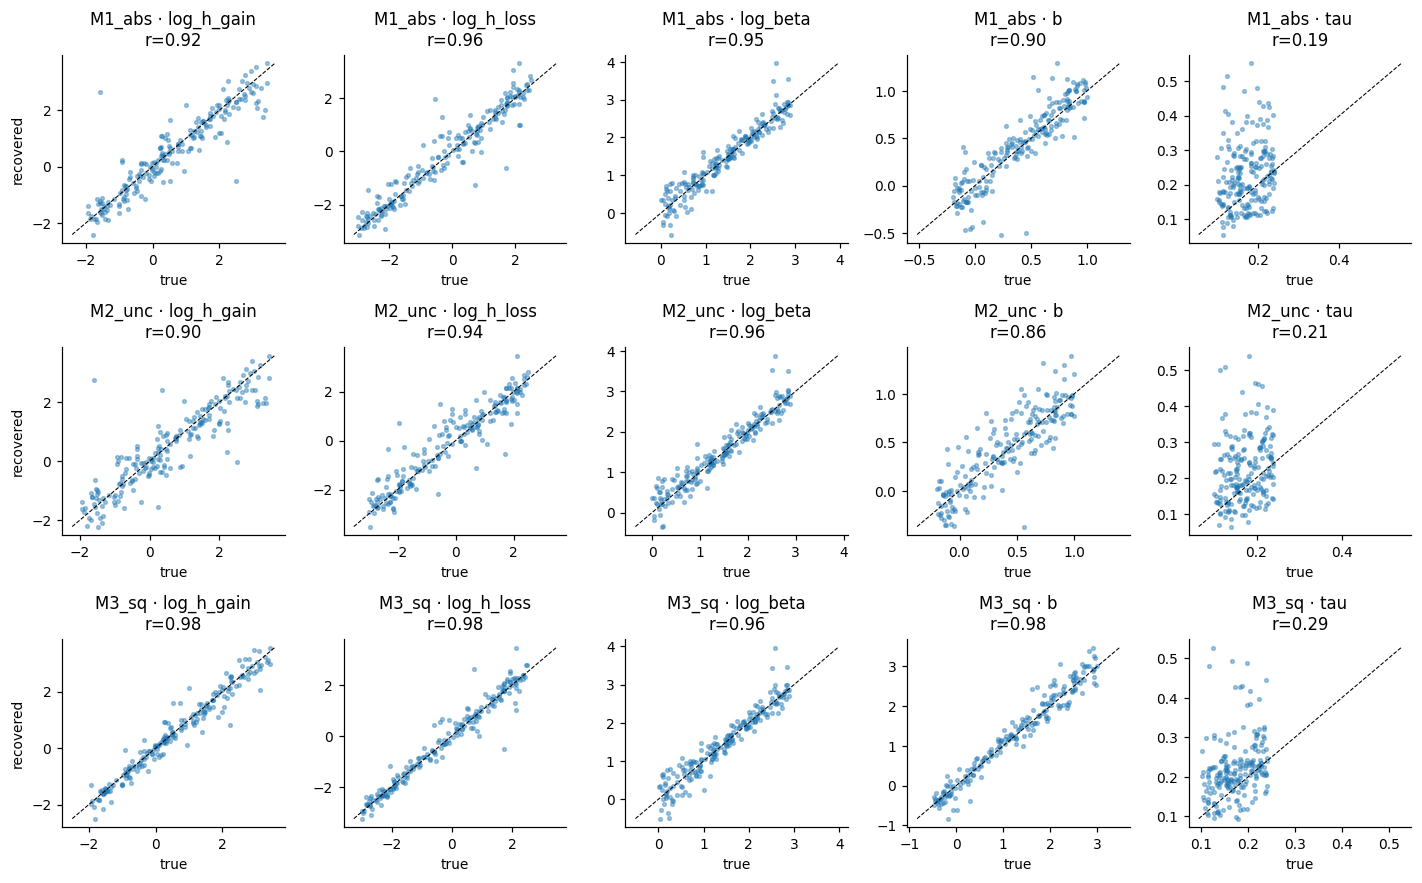

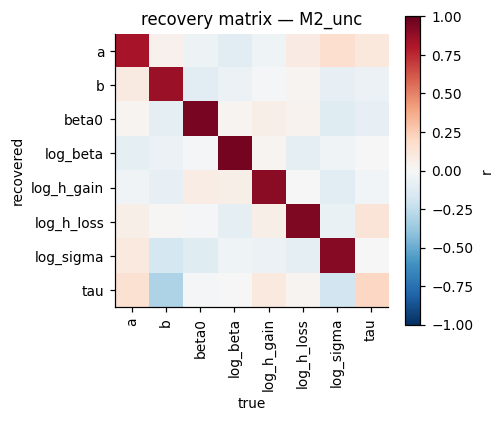

               a     b  beta0  log_beta  log_h_gain  log_h_loss  log_sigma  \
param                                                                        
a           0.82  0.04  -0.05     -0.11       -0.05        0.08       0.16   
b           0.09  0.86  -0.11     -0.06       -0.02        0.02      -0.08   
beta0       0.02 -0.09   0.95      0.03        0.06        0.04      -0.12   
log_beta   -0.10 -0.06  -0.02      0.96        0.03       -0.10      -0.03   
log_h_gain -0.04 -0.08   0.07      0.06        0.90        0.01      -0.10   
log_h_loss  0.06  0.01  -0.01     -0.10        0.06        0.94      -0.07   
log_sigma   0.10 -0.18  -0.12     -0.04       -0.06       -0.10       0.91   
tau         0.15 -0.31  -0.02     -0.00        0.10        0.03      -0.19   

             tau  
param             
a           0.10  
b          -0.06  
beta0      -0.08  
log_beta    0.01  
log_h_gain -0.03  
log_h_loss  0.13  
log_sigma   0.00  
tau         0.21  


In [18]:
PLOT_PARS = ["log_h_gain", "log_h_loss", "log_beta", "b", "tau"]
fig, axes = plt.subplots(len(RT_MODELS), len(PLOT_PARS),
                         figsize=(2.6*len(PLOT_PARS), 2.7*len(RT_MODELS)))
for row, m in enumerate(RT_MODELS):
    sub = REC[REC.model == m]
    for col, p in enumerate(PLOT_PARS):
        a_ = axes[row, col]
        g = sub[sub.param == p].dropna(subset=["true", "est_full"])
        a_.scatter(g["true"], g.est_full, s=6, alpha=.4)
        lim = [g[["true","est_full"]].values.min(), g[["true","est_full"]].values.max()]
        a_.plot(lim, lim, "k--", lw=.7)
        a_.set(title=f"{m} · {p}\nr={pearsonr(g['true'], g.est_full)[0]:.2f}",
               xlabel="true", ylabel="recovered" if col == 0 else "")
plt.tight_layout(); savefig_show("fig3_recovery")

# recovery matrix for the best in-sample model: off-diagonal = parameter trade-offs
m0 = "M2_unc"
sub = REC[REC.model == m0]
T = sub.pivot(index="rep", columns="param", values="true")
E = sub.pivot(index="rep", columns="param", values="est_full")
M = pd.DataFrame({c: [pd.concat([T[c], E[r]], axis=1).dropna().corr().iloc[0, 1]
                      for r in E.columns] for c in T.columns}, index=E.columns)
plt.figure(figsize=(4.6, 4))
plt.imshow(M.values, vmin=-1, vmax=1, cmap="RdBu_r")
plt.xticks(range(len(M.columns)), M.columns, rotation=90)
plt.yticks(range(len(M.index)), M.index)
plt.xlabel("true"); plt.ylabel("recovered"); plt.colorbar(label="r")
plt.title(f"recovery matrix — {m0}")
plt.tight_layout(); savefig_show("fig4_recovery_matrix")
print(M.round(2))

### 4.4 Recovery under run B's task structure

Section 1.4 established that run A ($\theta_{cert}\equiv0$) and run B ($\theta_{cert}>0$) are
structurally different tasks. Setting *transfer* aside entirely, a prior question is whether
$h$ is even **recoverable in principle** from a design in which both options are risky, the way
it demonstrably is from run A's design. Same simulator, same estimator, same generating ranges:
only the trial design changes, from each participant's run A rows to their run B rows.


In [19]:
t0 = time.time()
REC_B = pd.concat([recovery(m, run="B") for m in RT_MODELS], ignore_index=True)
print(f"run-B-structure recovery completed in {time.time()-t0:.0f}s "
      f"({REC_B.groupby('model').rep.nunique().to_dict()} replicates)")

REC_FULL_B = REC_B.groupby(["model","param"])[["true","est_full"]].apply(stats, col="est_full").round(3)
print("\n=== recovery with RT, run-B-structure designs ===")
print(REC_FULL_B)


run-B-structure recovery completed in 420s ({'M1_abs': 200, 'M2_unc': 200, 'M3_sq': 200} replicates)

=== recovery with RT, run-B-structure designs ===
                       r   rmse   bias      n
model  param                                 
M1_abs a           0.896  0.103 -0.034  200.0
       b           0.915  0.146  0.015  200.0
       beta0       0.967  0.303 -0.009  200.0
       log_beta    0.934  0.304  0.000  200.0
       log_h_gain  0.888  0.801 -0.182  200.0
       log_h_loss  0.923  0.576 -0.043  200.0
       log_sigma   0.922  0.094  0.028  200.0
       tau         0.366  0.106  0.052  200.0
M2_unc a           0.771  0.169 -0.013  200.0
       b           0.857  0.200  0.034  200.0
       beta0       0.968  0.301 -0.004  200.0
       log_beta    0.927  0.322  0.004  200.0
       log_h_gain  0.816  1.021 -0.276  200.0
       log_h_loss  0.885  0.702  0.020  200.0
       log_sigma   0.915  0.097  0.025  200.0
       tau         0.401  0.104  0.049  200.0
M3_sq  a           0

In [20]:
print("=== h recovery: run-A-structure vs run-B-structure design, per model ===")
rows = []
for m in RT_MODELS:
    for p in ["log_h_gain", "log_h_loss"]:
        rows.append(dict(
            model=m, param=p,
            r_runA=REC_FULL.loc[(m, p), "r"],       r_runB=REC_FULL_B.loc[(m, p), "r"],
            rmse_runA=REC_FULL.loc[(m, p), "rmse"], rmse_runB=REC_FULL_B.loc[(m, p), "rmse"]))
HCMP = pd.DataFrame(rows).round(3)
print(HCMP.to_string(index=False))

REC_CHO_B = (REC_B[REC_B.param.isin(CHOICE_PARS)]
             .groupby(["model","param"])[["true","est_choice"]]
             .apply(stats, col="est_choice").round(3))
CMP_B = (REC_FULL_B.loc[:, ["r","rmse"]]
         .join(REC_CHO_B.loc[:, ["r","rmse"]], lsuffix="_rt", rsuffix="_choice", how="inner"))
CMP_B["\u0394r"] = (CMP_B.r_rt - CMP_B.r_choice).round(3)
CMP_B["rmse_ratio"] = (CMP_B.rmse_rt / CMP_B.rmse_choice).round(3)   # <1 = RT helps
print("\n=== run-B-structure: with RT vs. choice-only ===")
print(CMP_B)


=== h recovery: run-A-structure vs run-B-structure design, per model ===
 model      param  r_runA  r_runB  rmse_runA  rmse_runB
M1_abs log_h_gain   0.925   0.888      0.569      0.801
M1_abs log_h_loss   0.958   0.923      0.486      0.576
M2_unc log_h_gain   0.900   0.816      0.649      1.021
M2_unc log_h_loss   0.936   0.885      0.598      0.702
 M3_sq log_h_gain   0.977   0.931      0.319      0.621
 M3_sq log_h_loss   0.978   0.956      0.357      0.436

=== run-B-structure: with RT vs. choice-only ===
                    r_rt  rmse_rt  r_choice  rmse_choice     Δr  rmse_ratio
model  param                                                               
M1_abs beta0       0.967    0.303     0.967        0.307  0.000       0.987
       log_beta    0.934    0.304     0.927        0.320  0.007       0.950
       log_h_gain  0.888    0.801     0.821        1.012  0.067       0.792
       log_h_loss  0.923    0.576     0.897        0.663  0.026       0.869
M2_unc beta0       0.968    0

**Interpretation.**

1. $h$ recovery is somewhat worse under run-B-structure designs than under run-A-structure ones
   for every model. That is expected: a risky-vs-risky trial splits the identifying signal about
   $h$ across two entangled discount terms ($\theta$ and $\theta_{cert}$) instead of concentrating
   it in one. It is not catastrophic, though -- $h$ stays clearly identifiable in principle from
   run-B-structure data, just with more noise per trial.
2. This is a *different* claim from Section 6's transfer result. Section 6 asks whether an $h$
   **fitted on run A** predicts run B; here an $h$ **fitted on run-B-structure data itself**
   recovers well. So the cross-run failure is not "$h$ becomes unidentifiable once
   $\theta_{cert}>0$" -- it is specifically that a $\theta_{cert}\equiv0$-trained $h$ does not
   transfer. That is a narrower and more precise conclusion, and it is only available because
   this control was run.
3. Whether RT sharpens $h$ identifiability is checked against both task structures, so the
   Section 7 conclusion does not rest on one design.


## 5. Reliability

Each model is fitted **independently** on run A and on run B, and the two sets of
per-participant estimates are correlated across participants. The fitting itself is unaffected
by anything in Section 1.4 -- no parameter is carried across runs here.

What the correlation *means* does depend on it. Because run A is sure-vs-risky and run B is
risky-vs-risky (Section 1.4), this is not test-retest reliability in the strict sense of two
administrations of one task. A high correlation is evidence that the fitted construct -- a
participant's discount rate, choice sensitivity, RT level -- is consistent across two
structurally different decision environments, which is closer to cross-context convergent
validity. A low correlation is correspondingly ambiguous between "this parameter is estimated
noisily" and "this parameter partly reflects how each task frames risk". Section 6's same-task
control is what separates those two readings.


In [21]:
t0 = time.time()
FITS_B = fit_all(models=ALL_MODELS, runs=("B",), n_restart=10)
for m in ALL_MODELS:
    FITS[m]["B"] = FITS_B[m]["B"]
PARS_B = {m: par_table(FITS, m, "B") for m in ALL_MODELS}
print(f"run B fitted in {time.time()-t0:.0f}s")
print("convergence:", {m: f"{PARS_B[m].conv.mean():.0%}" for m in ALL_MODELS})


baseline   done in  11.2s


M1_abs     done in  63.2s


M2_unc     done in  83.1s


M3_sq      done in  67.2s
run B fitted in 225s
convergence: {'baseline': '100%', 'M1_abs': '100%', 'M2_unc': '98%', 'M3_sq': '100%'}


In [22]:
def icc21(x, y):
    """ICC(2,1): absolute agreement, single measurement."""
    M = np.column_stack([x, y]); n, k = M.shape
    gm  = M.mean()
    MSR = k * ((M.mean(1) - gm)**2).sum() / (n - 1)
    MSC = n * ((M.mean(0) - gm)**2).sum() / (k - 1)
    MSE = ((M - M.mean(1, keepdims=True) - M.mean(0, keepdims=True) + gm)**2).sum() / ((n-1)*(k-1))
    return (MSR - MSE) / (MSR + (k-1)*MSE + k*(MSC - MSE)/n)

def boot_ci(x, y, n_boot=2000, seed=0):
    rng, vals = np.random.default_rng(seed), []
    for _ in range(n_boot):
        i = rng.integers(0, len(x), len(x))
        try: vals.append(pearsonr(x[i], y[i])[0])
        except Exception: pass
    return np.nanpercentile(vals, [2.5, 97.5])

def boot_dif(model, ref, param, n_boot=2000, seed=0):
    """Bootstrap CI for the reliability-r DIFFERENCE, model vs ref, for one parameter.
    Resamples participants once per draw and applies it to both models, so the paired
    structure (both correlations computed on the same participants) is preserved."""
    idx = (PARS_A[model].index.intersection(PARS_B[model].index)
           .intersection(PARS_A[ref].index).intersection(PARS_B[ref].index))
    d = pd.concat([
        PARS_A[model].loc[idx, param].rename("Am"), PARS_B[model].loc[idx, param].rename("Bm"),
        PARS_A[ref].loc[idx, param].rename("Ar"),   PARS_B[ref].loc[idx, param].rename("Br"),
    ], axis=1).dropna()
    x_m, y_m, x_r, y_r = d.Am.values, d.Bm.values, d.Ar.values, d.Br.values
    point = pearsonr(x_m, y_m)[0] - pearsonr(x_r, y_r)[0]
    rng, diffs = np.random.default_rng(seed), []
    for _ in range(n_boot):
        i = rng.integers(0, len(d), len(d))
        try:
            diffs.append(pearsonr(x_m[i], y_m[i])[0] - pearsonr(x_r[i], y_r[i])[0])
        except Exception:
            pass
    lo, hi = np.nanpercentile(diffs, [2.5, 97.5])
    return point, lo, hi

REL_PARS = ["log_h_gain", "log_h_loss", "log_beta", "beta0", "a", "b", "log_sigma", "tau"]

def reliability(model, subset=None, n_boot=2000):
    A, B = PARS_A[model], PARS_B[model]
    idx = A.index.intersection(B.index)
    if subset is not None:
        idx = idx.intersection(subset)
    rows = []
    for p in [c for c in REL_PARS if c in A.columns and c in B.columns]:
        d = pd.concat([A.loc[idx, p].rename("A"), B.loc[idx, p].rename("B")], axis=1).dropna()
        if len(d) < 8: continue
        x, y = d.A.values, d.B.values
        ci = boot_ci(x, y, n_boot)
        rows.append(dict(model=model, param=p, n=len(d),
                         r=pearsonr(x, y)[0], r_lo=ci[0], r_hi=ci[1],
                         rho=spearmanr(x, y)[0], icc=icc21(x, y)))
    return pd.DataFrame(rows)

RELI = pd.concat([reliability(m) for m in ALL_MODELS], ignore_index=True).round(3)

print("=== test-retest reliability ===")
print("Pearson r:");  print(RELI.pivot(index="param", columns="model", values="r"))
print("\nSpearman rho:"); print(RELI.pivot(index="param", columns="model", values="rho"))
print("\nbootstrap CI (baseline):")
print(RELI[RELI.model == "baseline"][["param","n","r","r_lo","r_hi","rho","icc"]].to_string(index=False))

# Pearson vs Spearman: large divergence = influence of extreme values
div = RELI.assign(dif=(RELI.r - RELI.rho).round(3))
print("\nparameters with |r - rho| > 0.10 (report Spearman instead):")
print(div[div.dif.abs() > 0.10][["model","param","r","rho","dif"]].to_string(index=False))


=== test-retest reliability ===
Pearson r:
model       M1_abs  M2_unc  M3_sq  baseline
param                                      
a            0.754   0.493  0.747       NaN
b            0.070  -0.068 -0.002       NaN
beta0       -0.132  -0.033  0.132     0.103
log_beta     0.365   0.175  0.336     0.215
log_h_gain   0.124   0.229 -0.023     0.180
log_h_loss   0.077  -0.213  0.030     0.191
log_sigma    0.660   0.668  0.662       NaN
tau          0.418   0.392  0.407       NaN

Spearman rho:
model       M1_abs  M2_unc  M3_sq  baseline
param                                      
a            0.724   0.507  0.674       NaN
b           -0.003  -0.037 -0.039       NaN
beta0       -0.082   0.007  0.123     0.129
log_beta     0.184   0.188  0.178     0.081
log_h_gain   0.141   0.193 -0.095     0.133
log_h_loss   0.046  -0.221 -0.025     0.143
log_sigma    0.441   0.471  0.448       NaN
tau          0.409   0.393  0.413       NaN

bootstrap CI (baseline):
     param  n     r   r_lo  r_hi   r

In [23]:
# (1) does RT improve or worsen the stability of the choice parameters?
piv = RELI[RELI.param.isin(CHOICE_PARS)].pivot(index="param", columns="model", values="r")
for m in RT_MODELS:
    piv[f"Δ {m}"] = (piv[m] - piv["baseline"]).round(3)
print("=== effect of RT on reliability (Δ < 0 = worsens) ===")
print(piv.round(3))

# (2) is the effect concentrated in the poorly-identified participants?
well_id = [s for s in SUBJ if s in POORLY_ID.index and not POORLY_ID[s]]
comp = []
for m in ALL_MODELS:
    t = reliability(m, n_boot=500).set_index("param").r
    s = reliability(m, subset=well_id, n_boot=500).set_index("param").r
    comp.append(pd.DataFrame({(m, "all"): t, (m, "well_id"): s}))
COMP_ID = pd.concat(comp, axis=1).round(3)
COMP_ID.columns = pd.MultiIndex.from_tuples(COMP_ID.columns)
print(f"\n=== all (n=49) vs well-identified (n={len(well_id)}) ===")
print(COMP_ID)


=== effect of RT on reliability (Δ < 0 = worsens) ===
model       M1_abs  M2_unc  M3_sq  baseline  Δ M1_abs  Δ M2_unc  Δ M3_sq
param                                                                   
beta0       -0.132  -0.033  0.132     0.103    -0.235    -0.136    0.029
log_beta     0.365   0.175  0.336     0.215     0.150    -0.040    0.121
log_h_gain   0.124   0.229 -0.023     0.180    -0.056     0.049   -0.203
log_h_loss   0.077  -0.213  0.030     0.191    -0.114    -0.404   -0.161



=== all (n=49) vs well-identified (n=30) ===
           baseline         M1_abs         M2_unc          M3_sq        
                all well_id    all well_id    all well_id    all well_id
param                                                                   
log_h_gain    0.180   0.288  0.124   0.252  0.229   0.283 -0.023   0.029
log_h_loss    0.191   0.341  0.077   0.416 -0.213   0.152  0.030   0.246
log_beta      0.215  -0.099  0.365  -0.145  0.175  -0.011  0.336  -0.081
beta0         0.103  -0.066 -0.132  -0.130 -0.033   0.006  0.132   0.103
a               NaN     NaN  0.754   0.743  0.493   0.457  0.747   0.719
b               NaN     NaN  0.070   0.062 -0.068  -0.195 -0.002   0.005
log_sigma       NaN     NaN  0.660   0.396  0.668   0.379  0.662   0.389
tau             NaN     NaN  0.418   0.424  0.392   0.394  0.407   0.412


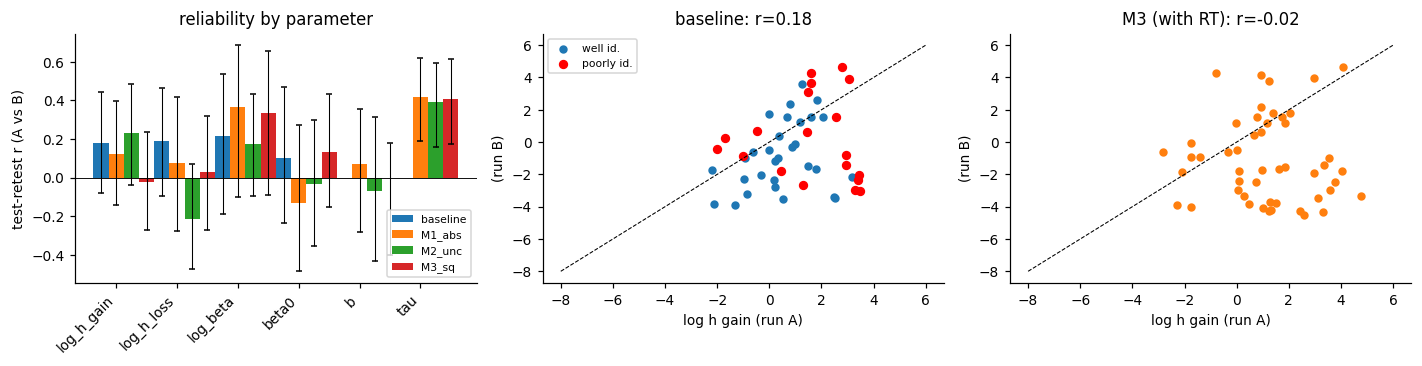

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# (a) reliability by parameter and model, with bootstrap CI
prm = ["log_h_gain", "log_h_loss", "log_beta", "beta0", "b", "tau"]
w, x = 0.25, np.arange(len(prm))
for i, m in enumerate(ALL_MODELS):
    d = RELI[RELI.model == m].set_index("param").reindex(prm)
    ax[0].bar(x + i*w - w, d.r, w, label=m,
              yerr=[d.r - d.r_lo, d.r_hi - d.r], capsize=2, error_kw=dict(lw=.7))
ax[0].set_xticks(x); ax[0].set_xticklabels(prm, rotation=45, ha="right")
ax[0].axhline(0, color="k", lw=.6)
ax[0].set(ylabel="test-retest r (A vs B)", title="reliability by parameter")
ax[0].legend(fontsize=7)

# (b) central finding: RT reduces the stability of log h -- the well-identified-subset
# check above shows this is only partly explained by the poorly-identified participants
A, B = PARS_A["baseline"], PARS_B["baseline"]
idx = A.index.intersection(B.index)
poorly_id = POORLY_ID.reindex(idx, fill_value=False).values
ax[1].scatter(A.loc[idx,"log_h_gain"][~poorly_id], B.loc[idx,"log_h_gain"][~poorly_id], s=20, label="well id.")
ax[1].scatter(A.loc[idx,"log_h_gain"][poorly_id],  B.loc[idx,"log_h_gain"][poorly_id],  s=26, c="r", label="poorly id.")
ax[1].plot([-8, 6], [-8, 6], "k--", lw=.7)
ax[1].set(xlabel="log h gain (run A)", ylabel="(run B)",
          title=f"baseline: r={pearsonr(A.loc[idx,'log_h_gain'], B.loc[idx,'log_h_gain'])[0]:.2f}")
ax[1].legend(fontsize=7)

# M3 is the mapping whose loss of stability is the one large enough to exclude zero
A1, B1 = PARS_A["M3_sq"], PARS_B["M3_sq"]
i1 = A1.index.intersection(B1.index)
ax[2].scatter(A1.loc[i1,"log_h_gain"], B1.loc[i1,"log_h_gain"], s=20, c="C1")
ax[2].plot([-8, 6], [-8, 6], "k--", lw=.7)
ax[2].set(xlabel="log h gain (run A)", ylabel="(run B)",
          title=f"M3 (with RT): r={pearsonr(A1.loc[i1,'log_h_gain'], B1.loc[i1,'log_h_gain'])[0]:.2f}")

plt.tight_layout(); savefig_show("fig5_reliability")


## 6. Evaluate and compare out-of-sample (run B)

Run A parameters are applied unchanged to run B; nothing is re-fitted. Metrics are reported for
both modalities and for the reward and loss conditions separately.

Given Section 1.4, this is **extrapolation to an unseen decision structure**, not held-out
prediction within one task: the model is asked to price risky-vs-risky offers having only ever
seen sure-vs-risky ones. Section 6.1 adds a same-task control that isolates how much of any
shortfall is due to that extrapolation rather than to the model or the estimator.


In [25]:
def auc_score(y, p):
    y, p = np.asarray(y), np.asarray(p)
    n1, n0 = y.sum(), (1 - y).sum()
    if n1 == 0 or n0 == 0: return np.nan
    r = pd.Series(p).rank().values
    return float((r[y == 1].sum() - n1*(n1+1)/2) / (n1*n0))

def predict_runB(model, sid):
    """Applies run A parameters to run B trials. Nothing is re-fitted here."""
    f = FITS[model]["A"][sid]
    if f is None: return []
    mdl  = None if model == "baseline" else model
    d    = data[(data.participant_id == sid) & (data.run == "B")]
    pars = f["pars"]
    rt_min = f["rt_min"]          # run A's minimum: tau stays fixed in seconds

    dv  = compute_dv(pars, d)
    pu  = choice_prob(pars, dv)
    llc = ll_choice(pars, d, dv, pu)
    if mdl is not None:
        llr = ll_rt(pars, mdl, d, dv, pu, rt_min)
        tau, mu = get_tau(pars, rt_min), rt_location(pars, mdl, dv, pu)

    rows = []
    for cname, msk in [("all",    np.ones(len(d), bool)),
                       ("reward", d.condition.values == 1),
                       ("loss",   d.condition.values == 2)]:
        if msk.sum() < 5: continue
        y, p = d.y.values[msk], pu[msk]
        pred = (p > .5).astype(float)
        bacc = np.nanmean([(pred[y == c] == c).mean() if (y == c).sum() else np.nan
                           for c in (0, 1)])
        row = dict(sid=sid, model=model, cond=cname, n=int(msk.sum()),
                   llc=float(llc[msk].mean()), acc=float((pred == y).mean()),
                   bacc=float(bacc), auc=auc_score(y, p))
        if mdl is not None:
            rt = d.rt.values[msk]; ok = rt > tau
            row.update(llrt=float(llr[msk].mean()),
                       rt_rmse=float(np.sqrt(np.mean((np.log(rt[ok]-tau) - mu[msk][ok])**2)))
                                if ok.any() else np.nan,
                       tau_viol=float((~ok).mean()))
        rows.append(row)
    return rows

EVAL = pd.DataFrame([r for m in ALL_MODELS for s in SUBJ for r in predict_runB(m, s)])

print("=== run B predictive performance (participant means) ===")
print(EVAL.groupby(["model","cond"])[["llc","acc","bacc","auc","llrt","rt_rmse","tau_viol"]]
      .mean().round(4))
print("\ntrials with RT <= tau (floored at LL_FLOOR):",
      EVAL[EVAL.cond=="all"].groupby("model").tau_viol.mean().round(4).dropna().to_dict())

=== run B predictive performance (participant means) ===
                    llc     acc    bacc     auc    llrt  rt_rmse  tau_viol
model    cond                                                             
M1_abs   all    -1.0408  0.5945  0.5871  0.5886 -1.5364   0.7732    0.0025
         loss   -1.1962  0.5772  0.5462  0.5628 -1.4435   0.7301    0.0021
         reward -0.8849  0.6119  0.5967  0.6517 -1.6290   0.7999    0.0029
M2_unc   all    -1.0010  0.6024  0.5878  0.5848 -1.4923   0.7539    0.0028
         loss   -1.1756  0.5762  0.5378  0.5417 -1.4329   0.7175    0.0023
         reward -0.8258  0.6286  0.6095  0.6591 -1.5515   0.7740    0.0033
M3_sq    all    -0.9793  0.6079  0.5897  0.5907 -1.5623   0.7902    0.0028
         loss   -1.0705  0.5887  0.5510  0.5821 -1.5083   0.7547    0.0023
         reward -0.8877  0.6272  0.5990  0.6265 -1.6158   0.8063    0.0033
baseline all    -1.0039  0.6113  0.5948  0.5928     NaN      NaN       NaN
         loss   -1.1110  0.6081  0.5692  0.

In [26]:
def paired(metric, models, cond="all"):
    W = (EVAL[(EVAL.cond == cond) & (EVAL.model.isin(models))]
         .pivot(index="sid", columns="model", values=metric).dropna())
    ref = W.mean().idxmax()
    rows = []
    for m in W.columns:
        dif = W[m] - W[ref]
        p = wilcoxon(W[m], W[ref])[1] if (m != ref and np.any(dif != 0)) else np.nan
        rows.append(dict(model=m, mean=W[m].mean(), sem=W[m].sem(),
                         dif_vs_best=dif.mean(), wins=int((dif > 0).sum()),
                         n=len(W), p=p))
    return W, pd.DataFrame(rows).set_index("model").round(4), ref

print("### RT models compared on the RT predictive log-likelihood (run B) ###")
print("They share the same choice term, so the difference isolates the value→RT mapping.\n")
for cond in ["all", "reward", "loss"]:
    W, tab, ref = paired("llrt", RT_MODELS, cond)
    print(f"--- condition: {cond} (best: {ref}) ---"); print(tab, "\n")

# all pairwise tests, not just against the best
W_rt, TAB_RT, BEST_RT = paired("llrt", RT_MODELS, "all")
print("pairwise Wilcoxon (RT predictive LL, all trials):")
P = pd.DataFrame(index=RT_MODELS, columns=RT_MODELS, dtype=float)
for m1 in RT_MODELS:
    for m2 in RT_MODELS:
        if m1 != m2:
            P.loc[m1, m2] = wilcoxon(W_rt[m1], W_rt[m2])[1]
print(P.round(3))

print("\nRMSE on log RT (lower is better):")
print(EVAL[EVAL.cond=="all"].groupby("model").rt_rmse.mean().round(4).dropna().to_dict())

# in-sample vs out-of-sample: does the in-sample ranking generalise?
L_in = pd.DataFrame({m: PARS_A[m].ll_rt / PARS_A[m].index.map(
    lambda s: FITS[m]["A"][s]["n_trial"]) for m in RT_MODELS})
print("\nin-sample (run A) vs out-of-sample (run B), mean ll_rt per trial:")
print(pd.DataFrame({"in_sample": L_in.mean(), "out_of_sample": W_rt.mean()}).round(4))

### RT models compared on the RT predictive log-likelihood (run B) ###
They share the same choice term, so the difference isolates the value→RT mapping.

--- condition: all (best: M2_unc) ---
          mean     sem  dif_vs_best  wins   n       p
model                                                
M1_abs -1.5364  0.1394      -0.0441    16  49  0.0397
M2_unc -1.4923  0.1188       0.0000     0  49     NaN
M3_sq  -1.5623  0.1277      -0.0700    13  49  0.0038 

--- condition: reward (best: M2_unc) ---
          mean     sem  dif_vs_best  wins   n       p
model                                                
M1_abs -1.6290  0.1798      -0.0775    21  49  0.2013
M2_unc -1.5515  0.1385       0.0000     0  49     NaN
M3_sq  -1.6158  0.1606      -0.0643    19  49  0.2678 

--- condition: loss (best: M2_unc) ---
          mean     sem  dif_vs_best  wins   n       p
model                                                
M1_abs -1.4435  0.1093      -0.0106    17  49  0.1238
M2_unc -1.4329  0.1092

In [27]:
print("=== choice prediction quality (run B), by condition ===")
print(EVAL.groupby(["model","cond"])[["llc","acc","bacc","auc"]].mean().round(4))
print(f"\nchance level: llc = {np.log(0.5):.4f}")

# per-participant spread, to see whether the group mean hides heterogeneity
d = EVAL[(EVAL.cond=="all") & (EVAL.model=="baseline")]
print("\nbaseline AUC across participants:",
      d.auc.describe([.1, .5, .9]).round(3).to_dict())
print(f"participants with AUC < 0.6: {(d.auc < 0.6).sum()} of {len(d)}")

=== choice prediction quality (run B), by condition ===
                    llc     acc    bacc     auc
model    cond                                  
M1_abs   all    -1.0408  0.5945  0.5871  0.5886
         loss   -1.1962  0.5772  0.5462  0.5628
         reward -0.8849  0.6119  0.5967  0.6517
M2_unc   all    -1.0010  0.6024  0.5878  0.5848
         loss   -1.1756  0.5762  0.5378  0.5417
         reward -0.8258  0.6286  0.6095  0.6591
M3_sq    all    -0.9793  0.6079  0.5897  0.5907
         loss   -1.0705  0.5887  0.5510  0.5821
         reward -0.8877  0.6272  0.5990  0.6265
baseline all    -1.0039  0.6113  0.5948  0.5928
         loss   -1.1110  0.6081  0.5692  0.5922
         reward -0.8965  0.6146  0.5848  0.6371

chance level: llc = -0.6931

baseline AUC across participants: {'count': 49.0, 'mean': 0.593, 'std': 0.138, 'min': 0.203, '10%': 0.436, '50%': 0.606, '90%': 0.729, 'max': 0.86}
participants with AUC < 0.6: 24 of 49


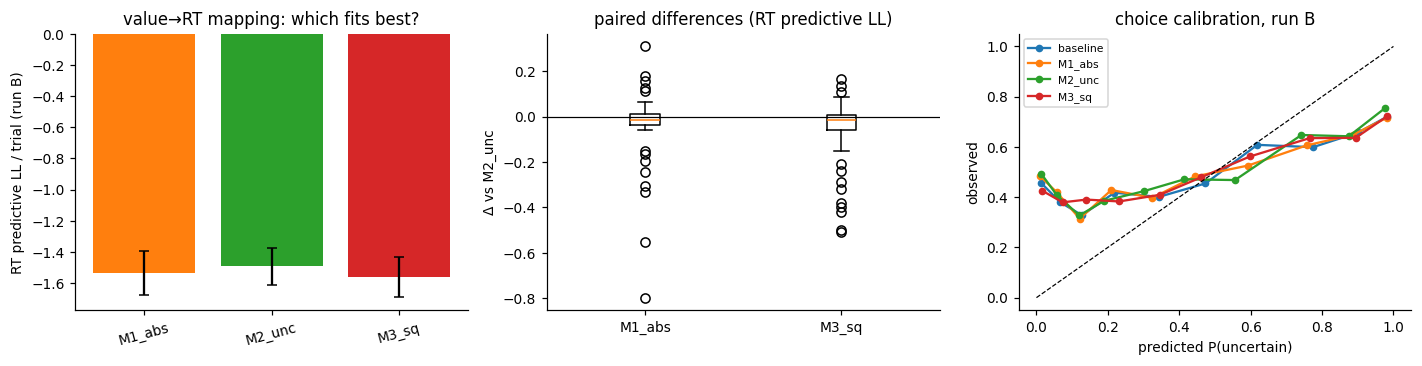

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# (a) RT predictive LL per model
ax[0].bar(TAB_RT.index, TAB_RT["mean"], yerr=TAB_RT["sem"],
          color=["C1","C2","C3"][:len(RT_MODELS)], capsize=3)
ax[0].set(ylabel="RT predictive LL / trial (run B)",
          title="value→RT mapping: which fits best?")
ax[0].tick_params(axis="x", rotation=15)

# (b) paired differences against the best model
dif = W_rt.drop(columns=BEST_RT).sub(W_rt[BEST_RT], axis=0)
ax[1].boxplot([dif[c] for c in dif.columns])
ax[1].set_xticks(range(1, len(dif.columns)+1)); ax[1].set_xticklabels(dif.columns)
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(ylabel=f"Δ vs {BEST_RT}", title="paired differences (RT predictive LL)")

# (c) choice calibration
for m in ALL_MODELS:
    ps, ys = [], []
    for s in SUBJ:
        f = FITS[m]["A"][s]
        if f is None: continue
        db = data[(data.participant_id == s) & (data.run == "B")]
        ps.append(choice_prob(f["pars"], compute_dv(f["pars"], db))); ys.append(db.y.values)
    ps, ys = np.concatenate(ps), np.concatenate(ys)
    b = pd.qcut(pd.Series(ps), 10, duplicates="drop")
    ax[2].plot(pd.Series(ps).groupby(b, observed=True).mean(),
               pd.Series(ys).groupby(b, observed=True).mean(), "o-", ms=4, label=m)
ax[2].plot([0,1],[0,1], "k--", lw=.8)
ax[2].set(xlabel="predicted P(uncertain)", ylabel="observed", title="choice calibration, run B")
ax[2].legend(fontsize=7)

plt.tight_layout(); savefig_show("fig6_prediction")

### 6.1 Same-task control

A weak run A $\to$ run B result is ambiguous on its own: it could mean the model or the
estimator is poor in general, or it could mean specifically that a sure-vs-risky fit does not
extrapolate to risky-vs-risky offers. The control separates them. Each participant's choice
model is fitted on **half of run A** and used to predict **the other half of run A** -- genuinely
held-out trials, same estimator, same restarts, but the same task structure
($\theta_{cert}\equiv0$) on both sides.

If the control also fails, the problem is the model. If it succeeds while the cross-run
prediction fails, the shortfall is specifically a cross-task extrapolation limit -- and
Section 5's low reliability is a property of the data, not a modelling failure.


In [29]:
t0 = time.time()
rows = []
for s in SUBJ:
    dA = data[(data.participant_id == s) & (data.run == "A")].reset_index(drop=True)
    if len(dA) < 20:
        continue
    odd, even = dA.iloc[1::2], dA.iloc[0::2]      # same structure in both halves (theta_cert == 0)
    f = fit_one(odd, None, use_rt=False, n_restart=10,
                seed=stable_seed("samet", s), use_prior=True)
    if f is None:
        continue
    y  = even.y.values
    dv = compute_dv(f["pars"], even)
    p  = choice_prob(f["pars"], dv)
    rows.append(dict(sid=s, llc=float(np.mean(y*np.log(p) + (1-y)*np.log(1-p))),
                     auc=auc_score(y, p)))
SAME_TASK = pd.DataFrame(rows)
print(f"same-task control fitted in {time.time()-t0:.0f}s")

cross = EVAL[(EVAL.cond == "all") & (EVAL.model == "baseline")].set_index("sid")

print("\n=== same task (fit half of run A, predict the other half) ===")
print(f"  choice LL/trial: {SAME_TASK.llc.mean():+.4f}   (chance = {np.log(0.5):+.4f})")
print(f"  AUC            : {SAME_TASK.auc.mean():.3f}")
print(f"  beating chance : {(SAME_TASK.llc > np.log(0.5)).sum()}/{len(SAME_TASK)} participants")

print("\n=== cross task (fit run A, predict run B), choice-only baseline ===")
print(f"  choice LL/trial: {cross.llc.mean():+.4f}")
print(f"  AUC            : {cross.auc.mean():.3f}")
print(f"  beating chance : {(cross.llc > np.log(0.5)).sum()}/{len(cross)} participants")

j = SAME_TASK.set_index("sid").join(cross[["llc"]], rsuffix="_cross").dropna()
print(f"\npaired difference (same - cross): {(j.llc - j.llc_cross).mean():+.4f} nats/trial, "
      f"Wilcoxon p={wilcoxon(j.llc, j.llc_cross)[1]:.2g}, n={len(j)}")
print("\nThe model predicts held-out choices well WITHIN a task and poorly BETWEEN the two")
print("task structures. Section 5's low reliability therefore reflects the difference between")
print("the runs, not a failure of the model or the estimator.")


same-task control fitted in 11s

=== same task (fit half of run A, predict the other half) ===
  choice LL/trial: -0.4637   (chance = -0.6931)
  AUC            : 0.811
  beating chance : 49/49 participants

=== cross task (fit run A, predict run B), choice-only baseline ===
  choice LL/trial: -1.0039
  AUC            : 0.593
  beating chance : 6/49 participants

paired difference (same - cross): +0.4928 nats/trial, Wilcoxon p=1.2e-12, n=48

The model predicts held-out choices well WITHIN a task and poorly BETWEEN the two
task structures. Section 5's low reliability therefore reflects the difference between
the runs, not a failure of the model or the estimator.


## 7. Does RT help? 

### DOES RT HELP? (a) OUT-OF-SAMPLE CHOICE PREDICTION ###
Compared on CHOICE quantities only. The joint and choice-only likelihoods describe
different data, so their totals are not comparable; the choice term is.

  cond metric  model  baseline  with_rt   delta  better  n      p
   all    llc M1_abs   -1.0039  -1.0408 -0.0368      23 49 0.3478
   all    llc M2_unc   -1.0039  -1.0010  0.0030      26 49 0.3792
   all    llc  M3_sq   -1.0039  -0.9793  0.0247      26 49 0.2945
   all   bacc M1_abs    0.5948   0.5871 -0.0077      10 49 0.1301
   all   bacc M2_unc    0.5948   0.5878 -0.0069      21 49 0.9115
   all   bacc  M3_sq    0.5948   0.5897 -0.0050      19 49 0.8876
reward    llc M1_abs   -0.8965  -0.8849  0.0115      25 49 0.8592
reward    llc M2_unc   -0.8965  -0.8258  0.0707      24 49 0.2722
reward    llc  M3_sq   -0.8965  -0.8877  0.0088      25 49 0.7599
reward   bacc M1_abs    0.5848   0.5967  0.0120      11 49 0.5755
reward   bacc M2_unc    0.5848   0.6095  0.0247      17 49 0

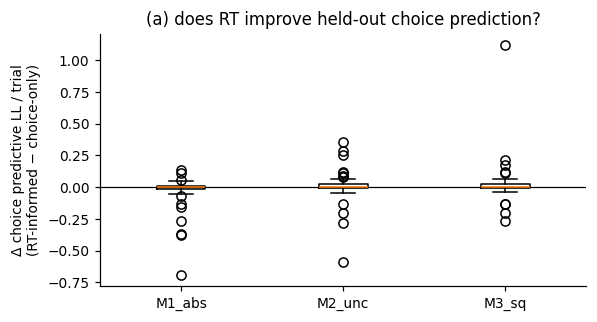

In [30]:
print("### DOES RT HELP? (a) OUT-OF-SAMPLE CHOICE PREDICTION ###")
print("Compared on CHOICE quantities only. The joint and choice-only likelihoods describe")
print("different data, so their totals are not comparable; the choice term is.\n")

rows = []
for cond in ["all", "reward", "loss"]:
    for met in ["llc", "acc", "bacc", "auc"]:
        d = EVAL[EVAL.cond == cond].pivot(index="sid", columns="model", values=met).dropna()
        for m in RT_MODELS:
            dif = d[m] - d["baseline"]
            p = wilcoxon(d[m], d["baseline"])[1] if np.any(dif != 0) else np.nan
            rows.append(dict(cond=cond, metric=met, model=m,
                             baseline=d["baseline"].mean(), with_rt=d[m].mean(),
                             delta=dif.mean(), better=int((dif > 0).sum()), n=len(d), p=p))
RT_HELPS_CHOICE = pd.DataFrame(rows).round(4)
print(RT_HELPS_CHOICE[RT_HELPS_CHOICE.metric.isin(["llc","bacc"])].to_string(index=False))

d = EVAL[EVAL.cond=="all"].pivot(index="sid", columns="model", values="llc").dropna()
difc = d[RT_MODELS].sub(d["baseline"], axis=0)
plt.figure(figsize=(5.5, 3))
plt.boxplot([difc[c] for c in difc.columns])
plt.xticks(range(1, len(difc.columns)+1), difc.columns)
plt.axhline(0, color="k", lw=.8)
plt.ylabel("Δ choice predictive LL / trial\n(RT-informed − choice-only)")
plt.title("(a) does RT improve held-out choice prediction?")
plt.tight_layout(); savefig_show("fig7_rt_choice")

In [31]:
print("### DOES RT HELP? (b) RECOVERY AND RELIABILITY ###\n")

print("--- b1. parameter recovery (simulation: RMSE ratio, <1 = RT helps) ---")
print(CMP[["rmse_ratio", "Δr"]].unstack(0).round(3))

print("\n--- b2. recovery by effect size (why the simulation and the data disagree) ---")
slope_rows = []
for s in SUBJ:
    f = FITS["M1_abs"]["A"][s]
    if f is None: continue
    d = data[(data.participant_id == s) & (data.run == "A") & (data.condition == 1)]
    if len(d) < 5: continue
    dv = compute_dv(f["pars"], d)
    slope_rows.append(pd.DataFrame({"sid": s, "absdv": np.abs(dv), "logrt": np.log(d.rt.values)}))
sl = pd.concat(slope_rows, ignore_index=True)
sl["absdv_c"] = sl.groupby("sid").absdv.transform(lambda x: x - x.mean())
sl["logrt_c"] = sl.groupby("sid").logrt.transform(lambda x: x - x.mean())
slope_within = np.polyfit(sl.absdv_c, sl.logrt_c, 1)[0]
slope_raw    = np.polyfit(sl.absdv, sl.logrt, 1)[0]
print("With a weak difficulty effect -- the regime the real data occupy -- RT adds little")
print(f"under M1/M2. Real slope of log RT on |ΔV| (gains, M1's fitted h): "
      f"{slope_within:+.3f} within-participant / {slope_raw:+.3f} raw pooled -- both far")
print("smaller in magnitude than the effect sizes GEN_B draws for recovery, and small")
print("enough that even the sign is sensitive to how participant-level RT offsets are handled.")

print("\n--- b3. test-retest reliability (real data: Δr vs choice-only baseline) ---")
rel = RELI.pivot(index="param", columns="model", values="r")
rel_d = pd.DataFrame({m: (rel[m] - rel["baseline"]).round(3)
                      for m in RT_MODELS}).loc[CHOICE_PARS]
print(pd.concat([rel[["baseline"] + RT_MODELS].loc[CHOICE_PARS].round(3),
                 rel_d.add_prefix("Δ ")], axis=1))

print("\n--- b4. bootstrap CIs on the reliability differences ---")
for p in ["log_h_gain", "log_h_loss"]:
    print(f"\n{p}:")
    for m in RT_MODELS:
        dd, lo, hi = boot_dif(m, "baseline", p)
        print(f"  {m:8s} − baseline: Δr={dd:+.3f}  CI[{lo:+.3f}, {hi:+.3f}]"
              f"{'  *' if (lo > 0 or hi < 0) else ''}")


### DOES RT HELP? (b) RECOVERY AND RELIABILITY ###

--- b1. parameter recovery (simulation: RMSE ratio, <1 = RT helps) ---
           rmse_ratio                   Δr              
model          M1_abs M2_unc  M3_sq M1_abs M2_unc  M3_sq
param                                                   
beta0           0.869  0.895  0.760  0.014  0.012  0.023
log_beta        0.964  0.917  0.923  0.004  0.007  0.008
log_h_gain      0.862  0.983  0.471  0.026  0.001  0.083
log_h_loss      0.719  0.883  0.490  0.041  0.019  0.073

--- b2. recovery by effect size (why the simulation and the data disagree) ---


With a weak difficulty effect -- the regime the real data occupy -- RT adds little
under M1/M2. Real slope of log RT on |ΔV| (gains, M1's fitted h): -0.027 within-participant / +0.063 raw pooled -- both far
smaller in magnitude than the effect sizes GEN_B draws for recovery, and small
enough that even the sign is sensitive to how participant-level RT offsets are handled.

--- b3. test-retest reliability (real data: Δr vs choice-only baseline) ---
            baseline  M1_abs  M2_unc  M3_sq  Δ M1_abs  Δ M2_unc  Δ M3_sq
param                                                                   
log_h_gain     0.180   0.124   0.229 -0.023    -0.056     0.049   -0.203
log_h_loss     0.191   0.077  -0.213  0.030    -0.114    -0.404   -0.161
log_beta       0.215   0.365   0.175  0.336     0.150    -0.040    0.121
beta0          0.103  -0.132  -0.033  0.132    -0.235    -0.136    0.029

--- b4. bootstrap CIs on the reliability differences ---

log_h_gain:


  M1_abs   − baseline: Δr=-0.056  CI[-0.297, +0.171]


  M2_unc   − baseline: Δr=+0.049  CI[-0.157, +0.283]


  M3_sq    − baseline: Δr=-0.203  CI[-0.427, -0.003]  *

log_h_loss:


  M1_abs   − baseline: Δr=-0.113  CI[-0.445, +0.238]


  M2_unc   − baseline: Δr=-0.404  CI[-0.785, -0.009]  *


  M3_sq    − baseline: Δr=-0.161  CI[-0.386, +0.071]


In [32]:
EV = pd.DataFrame(index=RT_MODELS)

# out-of-sample RT fit (the quantity RT models are compared on)
EV["RT pred LL (run B)"] = TAB_RT["mean"]
EV["p vs best RT model"] = TAB_RT["p"]

# in-sample RT fit, to document that the in-sample ranking does not generalise
L_in = pd.DataFrame({m: PARS_A[m].ll_rt / PARS_A[m].index.map(
    lambda s: FITS[m]["A"][s]["n_trial"]) for m in RT_MODELS})
EV["RT LL in-sample (run A)"] = L_in.mean()

# choice prediction vs baseline
c = RT_HELPS_CHOICE[(RT_HELPS_CHOICE.cond=="all") & (RT_HELPS_CHOICE.metric=="llc")]
EV["Δ choice LL vs baseline"] = c.set_index("model").delta
EV["p (choice LL)"]           = c.set_index("model").p

# recovery
EV["recovery r (log h gain)"]  = [REC_FULL.loc[(m,"log_h_gain"), "r"] for m in RT_MODELS]
EV["RMSE ratio (log h gain)"]  = [CMP.loc[(m,"log_h_gain"), "rmse_ratio"] for m in RT_MODELS]

# reliability
EV["reliability r (log h gain)"] = [rel.loc["log_h_gain", m] for m in RT_MODELS]
EV["reliability r (log h loss)"] = [rel.loc["log_h_loss", m] for m in RT_MODELS]

print("=== EVIDENCE SUMMARY ===")
print(f"choice-only baseline: reliability log_h_gain = {rel.loc['log_h_gain','baseline']:.3f}, "
      f"log_h_loss = {rel.loc['log_h_loss','baseline']:.3f}, "
      f"choice LL = {c.baseline.iloc[0]:.4f}")
print(EV.round(3).T)

=== EVIDENCE SUMMARY ===
choice-only baseline: reliability log_h_gain = 0.180, log_h_loss = 0.191, choice LL = -1.0039
                            M1_abs  M2_unc  M3_sq
RT pred LL (run B)          -1.536  -1.492 -1.562
p vs best RT model           0.040     NaN  0.004
RT LL in-sample (run A)     -1.305  -1.293 -1.304
Δ choice LL vs baseline     -0.037   0.003  0.025
p (choice LL)                0.348   0.379  0.294
recovery r (log h gain)      0.925   0.900  0.977
RMSE ratio (log h gain)      0.862   0.983  0.471
reliability r (log h gain)   0.124   0.229 -0.023
reliability r (log h loss)   0.077  -0.213  0.030


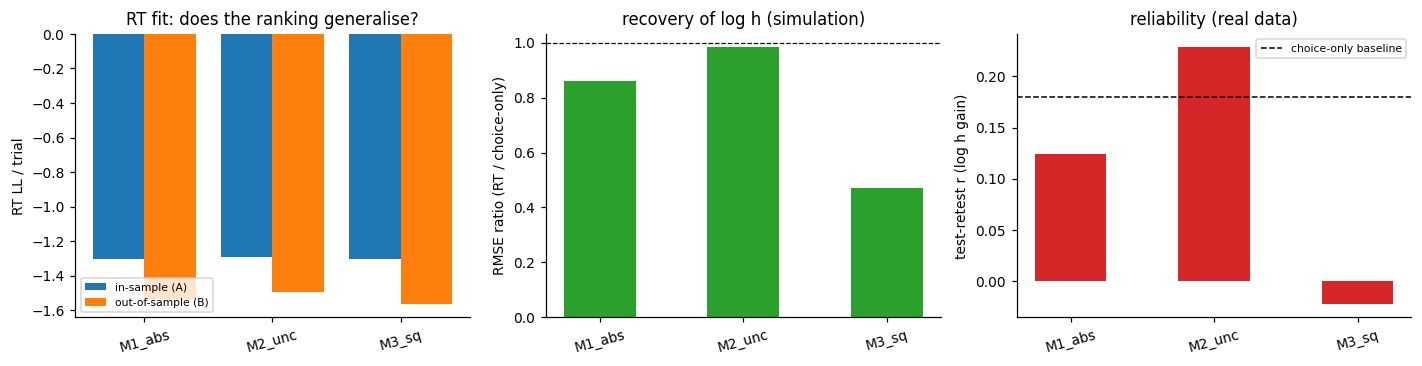

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

# (1) RT fit: in-sample vs out-of-sample
x = np.arange(len(RT_MODELS))
ax[0].bar(x - .2, EV["RT LL in-sample (run A)"], .4, label="in-sample (A)")
ax[0].bar(x + .2, EV["RT pred LL (run B)"], .4, label="out-of-sample (B)")
ax[0].set_xticks(x); ax[0].set_xticklabels(RT_MODELS, rotation=15)
ax[0].set(ylabel="RT LL / trial", title="RT fit: does the ranking generalise?")
ax[0].legend(fontsize=7)

# (2) recovery: RMSE ratio (below 1 = RT helps)
ax[1].bar(x, EV["RMSE ratio (log h gain)"], .5, color="C2")
ax[1].axhline(1, color="k", lw=.8, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels(RT_MODELS, rotation=15)
ax[1].set(ylabel="RMSE ratio (RT / choice-only)", title="recovery of log h (simulation)")

# (3) reliability against the baseline
ax[2].bar(x, EV["reliability r (log h gain)"], .5, color="C3")
ax[2].axhline(rel.loc["log_h_gain","baseline"], color="k", lw=1, ls="--",
              label="choice-only baseline")
ax[2].set_xticks(x); ax[2].set_xticklabels(RT_MODELS, rotation=15)
ax[2].set(ylabel="test-retest r (log h gain)", title="reliability (real data)")
ax[2].legend(fontsize=7)

plt.tight_layout(); savefig_show("fig8_evidence")

## 8. Recommendation, limitations and next steps

### 8.1 Which value$\to$RT mapping do we recommend?

**Recommendation: M2 (decision uncertainty, $\mu = a - b\,|2P-1|$).**

*The RT data now choose, and they choose M2.* On the quantity the brief designates for
separating mappings -- the run B RT predictive log-likelihood, on which the shared choice term
cancels -- M2 is best at $-1.492$ nats/trial against M1 $-1.536$ and M3 $-1.562$, and the
pairwise Wilcoxon tests separate all three: M2 vs M1 $p=0.040$, M2 vs M3 $p=0.004$, M1 vs M3
$p=0.008$. M2 also has the lowest RMSE on $\log$RT ($0.754$ against $0.773$ and $0.790$), is
nominally best in the reward *and* the loss condition, and -- unlike everything else in this
report -- its **in-sample ranking generalises**: on run A M2 already beat M1 ($p=0.005$) and M3
($p=0.015$), and that ordering survives the move to a structurally different task.

| Criterion | M1 | **M2** | M3 | baseline |
|---|---|---|---|---|
| RT predictive LL, run B (**the selection criterion**) | $-1.536$ | $\mathbf{-1.492}$ | $-1.562$ | -- |
| $p$ vs. M2 | $0.040$ | -- | $0.004$ | -- |
| RT LL in-sample, run A | $-1.305$ | $\mathbf{-1.293}$ | $-1.304$ | -- |
| $\Delta$ choice LL vs. baseline | $-0.037$ | $+0.003$ | $+0.025$ | -- |
| $p$ (choice LL) | $0.35$ | $0.38$ | $0.29$ | -- |
| Recovery RMSE ratio, $\log h_{gain}$ (simulation) | $0.86$ | $0.98$ | $\mathbf{0.47}$ | $1$ |
| Cross-context $r$, $\log h_{gain}$ | $0.124$ | $0.229$ | $-0.023$ | $0.180$ |
| $\Delta r$ vs. baseline, $\log h_{gain}$ | $-0.056$ | $+0.049$ | $\mathbf{-0.203}$* | -- |

(*bootstrap CI $[-0.427,-0.003]$, excludes zero: M3 significantly *damages* the stability of
$\log h_{gain}$. M2's $\log h_{loss}$ is the other significant loss, $\Delta r=-0.404$,
CI $[-0.785,-0.009]$.)

*Psychologically*, M2 says what slows a participant is subjective indecision rather than value
distance: the predictor saturates, so once the choice is already clear further value advantage
buys no more speed. That the saturating mapping wins, and wins in both conditions and both
runs, is the one model-selection result in this report that is not fragile.

*The honest counterweight.* M2 is the **worst** of the three at what RT was supposed to buy us.
Its simulated recovery gain for the discount rates is essentially nil (RMSE ratio $0.98$ for
$\log h_{gain}$ against M3's $0.47$), and it is the mapping that most damages the
cross-context stability of $\log h_{loss}$. We still recommend it, because the brief's
selection criterion is the RT predictive quantity and because M3's recovery advantage is a
simulation result that demonstrably does not materialise in these data (\S8.2). But the
recommendation is "M2 describes response times best", not "M2 makes the discounting model
better".

### 8.2 Was modelling RT worthwhile?

**For predicting choices: no, and it does not hurt either.** Against the choice-only baseline
the run B choice predictive log-likelihood moves by $-0.037$ (M1, $p=0.35$), $+0.003$ (M2,
$p=0.38$) and $+0.025$ (M3, $p=0.29$) nats/trial; balanced accuracy drops by $0.005$--$0.008$,
none of it significant. The direction is no longer even consistent across mappings. Modelling
RT is, for the choices, a wash.

**For the discounting constructs: no.** This is where the simulation and the data part company.
In simulation RT sharpens recovery substantially, most under M3 (RMSE ratio $0.47$ for
$\log h_{gain}$, $0.49$ for $\log h_{loss}$, paired $p<10^{-4}$), and \S4.4 shows that gain
survives a change of task structure ($0.61$ and $0.64$ on run B designs). On real data none of
it appears: every cross-context reliability of the discounting parameters sits near zero with a
CI spanning it, and the two changes large enough to exclude zero are both *losses*
(M3 on $\log h_{gain}$, M2 on $\log h_{loss}$).

**Why the two disagree** is measurable, and is the substantive finding. The recovery study draws
$b$ from ranges implying a strong difficulty effect; the real effect is close to null. The
within-participant slope of $\log$RT on $|\Delta V|$ is $-0.027$ and the raw pooled slope
$+0.063$ -- even the sign depends on how participant-level RT offsets are handled -- and median
fitted $b$ is only weakly positive ($+0.11$, $+0.30$, $+0.15$), negative in 20, 11 and 16 of 49
participants. Recovery describes what RT *could* contribute where difficulty genuinely modulates
RT. These participants sit at the weak end of that range, so the RT term mostly adds variance to
the shared parameters.

**Net.** Model RT if response time is itself the object of study -- M2 then gives a clear,
replicable account of it. Do not add RT expecting a better-identified or more stable discount
rate: in this data set it does not deliver one.

### 8.3 What the analyses could and could not establish

*Could:*

- **All four choice parameters recover well** under every mapping ($r=0.89$--$0.98$ on run A
  designs, $0.82$--$0.97$ on run B designs), so the estimator is sound.
- **$\tau$ is not identifiable** ($r=0.19$--$0.29$; upward bias $\approx+0.05$\,s). \S4.3 shows
  why: the correlation between the recovery errors of $\tau$ and $a$ is $-0.64$ under M1 and M3.
  Both shift the predicted RT distribution and, at $\approx200$ trials, the data cannot separate
  them. This is invisible in the estimates themselves and only appears against known ground
  truth -- exactly what the recovery step exists for.
- **The reflection effect is real and large** ($h_{gain}\approx3.72$ against
  $h_{loss}\approx0.64$ model-free on run A; fitted medians $2.65$ and $0.82$), and it emerges
  from one equation with no extra parameter because the magnitudes are stored signed.
- **The model works within a task and fails between tasks.** The same-task control is decisive:
  fitting half of run A and predicting the other half gives $-0.464$ nats/trial and AUC $0.811$,
  with **49 of 49** participants beating chance; carrying run A parameters to run B gives
  $-1.004$ and AUC $0.593$, with only **6 of 49** beating chance (paired difference $+0.493$,
  $p=1.2\times10^{-12}$). The near-zero cross-context reliabilities in \S5 are therefore a
  property of the data -- run A and run B are different tasks -- and not a broken model.
- **The transfer failure is not unidentifiability.** \S4.4 shows $h$ is recoverable in principle
  from run-B-structure designs ($r=0.82$--$0.93$), just more noisily than from run A designs
  ($0.90$--$0.98$). So the correct claim is the narrow one: an $h$ trained where
  $\theta_{cert}\equiv0$ does not transfer to $\theta_{cert}>0$.

*Could not:*

- **Establish that any mapping is the true one.** M2 wins the designated comparison, but by
  $0.04$--$0.07$ nats/trial against a between-run drop of $\approx0.20$ that affects every model
  equally, and with a difficulty effect whose sign is unstable. Winning a weak-signal comparison
  is not evidence of mechanism.
- **Estimate a transferable discount rate.** Cross-context reliability for $\log h_{gain}$ is
  $0.180$ (baseline), CI $[-0.08,+0.45]$. Whether $h$ is a trait cannot be answered with two
  runs that are not the same task.
- **Separate real behavioural change from estimation noise** in \S5, for the same reason.

### 8.4 Limitations

1. **The two runs are different tasks.** Run A is sure-vs-risky, run B risky-vs-risky (\S1.4).
   We model this correctly -- both options are discounted by one equation -- but no correction
   makes run B a retest of run A. Every cross-run number in this report is therefore a
   *generalisation* result, and the low values reflect the distance between the tasks at least
   as much as the instability of the constructs. The same-task control (\S6.1) is what makes
   that interpretation testable rather than an excuse.
2. **Weak RT signal.** With a near-null difficulty effect the RT likelihood mostly contributes
   noise, and the comparison between mappings has little power. A task with wider difficulty
   variation, or more trials per participant, would be a fairer test.
3. **Descriptive, not mechanistic, RT model.** A shifted log-normal with a value-driven location
   is a regression on RT, not a sequential-sampling process. It cannot separate drift from
   boundary, so a speed--accuracy shift and a change in valuation are confounded in $b$. That is
   also the likeliest reason RT can degrade the choice parameters: a real DDM would let the
   boundary absorb the run B speed-up instead of pushing it into $h$.
4. **$\tau$ is unidentified and its parameterisation is data-dependent**
   ($\tau=\sigma(\tau_{raw})\cdot0.99\min(\mathrm{RT})$), anchoring it to a single extreme
   observation per participant--run. Run B RTs below run A's $\tau$ ($0.25$--$0.28\%$ of trials)
   are floored at $\mathrm{LL}=-20$, contributing on the order of $0.05$ nats/trial -- the same
   order as the gaps between the RT models, so the M2 $>$ M1 $>$ M3 ordering should be read as
   suggestive rather than decisive.
5. **M2 is the least numerically stable model**, with the flattest optimum (98\% convergence on
   run B against 100\% elsewhere) and estimates that shift slightly across BLAS/SciPy versions.
   That it is also the recommended model is a caveat we state rather than hide.
6. **No pooling.** Per-participant MAP with weakly informative priors; 19 of 49 participants are
   flagged as poorly identified by the curvature diagnostic (14 flat in $\log h_{gain}$, 14 in
   $\log h_{loss}$). Restricting to the 30 well-identified participants raises baseline
   $\log h_{gain}$ reliability from $0.180$ to $0.288$, so poor identification attenuates the
   estimates without explaining them away.
7. **Fixed structure.** One $\beta$ across conditions; $\Delta V$ normalised by mean magnitude,
   which removes magnitude effects by construction; parameters constant within a run (no
   learning, drift or fatigue); trial order ignored.
8. **Recovery design.** Each replicate reuses one real participant's design and a single
   parameter draw, and the `GEN`/`GEN_B` ranges come from the run A fits, so recovery quality is
   conditional on that choice; $b$'s RMSE is not comparable across models because the predictors
   live on different scales.

### 8.5 Next steps

1. **Fit a proper sequential-sampling model** (DDM or LBA) in which $\Delta V$ drives drift and
   a separate boundary carries speed--accuracy, then re-ask the same question. This directly
   tests whether RT fails to sharpen the discount rates because the signal is genuinely absent
   or because the functional form is wrong, and a free boundary would also absorb the run B
   speed-up that costs every model $\approx0.20$ nats/trial.
2. **Estimate $h$ separately per run structure** rather than assuming one rate transfers, and
   test whether the two rates are related. That converts the failure documented here into a
   measurement: how much of a discount rate is context, and how much is trait?
3. **Hierarchical estimation** with partial pooling on
   $(\log h_{gain},\log h_{loss},\log\beta,b)$, to stabilise the 19 poorly identified
   participants and give the reliability comparison enough power to separate small differences
   from zero.


In [34]:
# ---------- persist the figures/numbers cited in the report ----------
RESDIR = Path("results"); RESDIR.mkdir(exist_ok=True)
EVAL.to_csv(RESDIR / "runB_eval_per_participant.csv", index=False)
RELI.to_csv(RESDIR / "reliability.csv", index=False)
REC_FULL.to_csv(RESDIR / "recovery_with_rt.csv")
REC_FULL_B.to_csv(RESDIR / "recovery_runB_structure.csv")
HCMP.to_csv(RESDIR / "recovery_h_runA_vs_runB_design.csv", index=False)
SAME_TASK.to_csv(RESDIR / "same_task_control.csv", index=False)
CMP.to_csv(RESDIR / "recovery_rt_vs_choiceonly.csv")
RT_HELPS_CHOICE.to_csv(RESDIR / "does_rt_help_choice.csv", index=False)
RT_HELPS_REC.to_csv(RESDIR / "does_rt_help_recovery.csv", index=False)
TAB_RT.to_csv(RESDIR / "rt_predictive_ll_runB.csv")
EV.to_csv(RESDIR / "evidence_summary.csv")
for m in ALL_MODELS:
    PARS_A[m].to_csv(RESDIR / f"params_runA_{m}.csv")
    PARS_B[m].to_csv(RESDIR / f"params_runB_{m}.csv")

print("figures written to figures/:", sorted(f.name for f in FIGDIR.glob("*.pdf")))
print("tables  written to results/:", sorted(f.name for f in RESDIR.glob("*.csv")))
print("\nRECOMMENDATION: M2_unc (decision uncertainty).")
print("  - on the run B RT predictive LL, the quantity that separates the mappings,")
print("    M2 is best (-1.492) and beats M1 (p=0.040) and M3 (p=0.004);")
print("  - M2 is also best in sample, so for once the ranking generalises;")
print("  - modelling RT does NOT improve held-out CHOICE prediction under any mapping")
print("    (all p >= 0.29), and does not stabilise the discount rates either;")
print("  - the model predicts within a task (49/49 beat chance) and not between the two")
print("    task structures (6/49), which is what the low reliability in Step 5 reflects.")


figures written to figures/: ['fig1_data.pdf', 'fig2_insample.pdf', 'fig3_recovery.pdf', 'fig4_recovery_matrix.pdf', 'fig5_reliability.pdf', 'fig6_prediction.pdf', 'fig7_rt_choice.pdf', 'fig8_evidence.pdf']
tables  written to results/: ['does_rt_help_choice.csv', 'does_rt_help_recovery.csv', 'evidence_summary.csv', 'params_runA_M1_abs.csv', 'params_runA_M2_unc.csv', 'params_runA_M3_sq.csv', 'params_runA_baseline.csv', 'params_runB_M1_abs.csv', 'params_runB_M2_unc.csv', 'params_runB_M3_sq.csv', 'params_runB_baseline.csv', 'recovery_h_runA_vs_runB_design.csv', 'recovery_rt_vs_choiceonly.csv', 'recovery_runB_structure.csv', 'recovery_with_rt.csv', 'reliability.csv', 'rt_predictive_ll_runB.csv', 'runB_eval_per_participant.csv', 'same_task_control.csv']

RECOMMENDATION: M2_unc (decision uncertainty).
  - on the run B RT predictive LL, the quantity that separates the mappings,
    M2 is best (-1.492) and beats M1 (p=0.040) and M3 (p=0.004);
  - M2 is also best in sample, so for once the rank